## Import Library

In [1]:

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import time
import json, pickle, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.utils import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import (
    Embedding, LSTM, GRU, Dense, Dropout,
    Bidirectional, GlobalMaxPool1D, Conv1D,
    MaxPooling1D, BatchNormalization, Flatten, GlobalAveragePooling1D,
)
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras.layers import Layer
import datetime
from collections import Counter


from transformers import BertTokenizer, TFBertModel

print(f"✓ TensorFlow  : {tf.__version__}")
print(f"✓ Transformers: {__import__('transformers').__version__}")


✓ TensorFlow  : 2.15.0
✓ Transformers: 4.38.2


In [2]:
# Inisiasi variabel Global
RANDOM_SEED   = 42
NUM_WORDS     = 10000
MAX_LENGTH    = 200
EMBED_DIM     = 128
EPOCH         = 50
BATCH_SIZE    = 32
OUTPUT_DIR    = './results'
ARTIFACTS_DIR  = './results/artifacts'
LOGS_DIR      = './results/logs'
ALL_MODELS_DIR  = './results/all_models'
BEST_MODEL_DIR   = './results/best_model'
DATASET_PATH   = 'D:\\Farizky\\casptoneAfterCrash\\healmate_ai\\AI\\eksperimen2\\farizky\\Emotion Dataset Merged.xlsx'  

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
#tes

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
os.makedirs(LOGS_DIR, exist_ok=True)
os.makedirs(ALL_MODELS_DIR, exist_ok=True)
os.makedirs(BEST_MODEL_DIR, exist_ok=True)
LOG_DIR = os.path.join(LOGS_DIR, datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

## Load Dataset

In [3]:
df =pd.read_excel(DATASET_PATH)
print(f'Shape : {df.shape}')
df.head()

Shape : (6403, 7)


,input_clean,input_no_punct,anger_prob,anxiety_prob,acceptance_prob,predicted_emotion,emotion_confidence
0,i am feeling unloved and unwanted and as if th...,i am feeling unloved and unwanted and as if th...,0.211942,0.211942,0.576117,acceptance,0.576117
1,i am fighting with my mind trying to tell myse...,i am fighting with my mind trying to tell myse...,0.106507,0.786986,0.106507,anxiety,0.786986
2,i felt i won an argument afterwards i felt mys...,i felt i won an argument afterwards i felt mys...,0.211942,0.211942,0.576117,acceptance,0.576117
3,i felt as if i was fighting a battle that i wa...,i felt as if i was fighting a battle that i wa...,0.045279,0.045279,0.909443,acceptance,0.909443
4,i miss you i miss the chats but it is the any ...,i miss you i miss the chats but it is the any ...,0.114195,0.843795,0.042010,anxiety,0.843795


## EDA

In [4]:
df.info()
print('\nMissing values:')
print(df.isnull().sum())
print(f'\nDuplikat : {df.duplicated().sum()}')
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 6403 entries, 0 to 6402
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   input_clean         6403 non-null   str    
 1   input_no_punct      6403 non-null   str    
 2   anger_prob          6403 non-null   float64
 3   anxiety_prob        6403 non-null   float64
 4   acceptance_prob     6403 non-null   float64
 5   predicted_emotion   6403 non-null   str    
 6   emotion_confidence  6403 non-null   float64
dtypes: float64(4), str(3)
memory usage: 350.3 KB

Missing values:
input_clean           0
input_no_punct        0
anger_prob            0
anxiety_prob          0
acceptance_prob       0
predicted_emotion     0
emotion_confidence    0
dtype: int64

Duplikat : 0


,anger_prob,anxiety_prob,acceptance_prob,emotion_confidence
count,6403.000000,6403.000000,6403.000000,6403.000000
mean,0.408670,0.337699,0.253632,0.656738
std,0.276955,0.261953,0.207724,0.165127
min,0.000017,0.000017,0.000017,0.344535
25%,0.211942,0.194653,0.106507,0.576117
50%,0.327732,0.211942,0.211942,0.576117
75%,0.576117,0.576117,0.327732,0.786986
max,0.999967,0.999967,0.998180,0.999967


In [5]:

#Distribusi panjang teks
df['input_length'] = df['input_clean'].str.split().str.len()
df['label_length'] = df['predicted_emotion'].str.split().str.len()
print(df[['input_length', 'label_length']].describe())

#Cek duplikat input (input sama, label berbeda)
print(f"Input unik: {df['input_clean'].nunique()} dari {len(df)} total")

#Cek label noise (confidence rendah)
print(df[df['emotion_confidence'] < 0.5]['predicted_emotion'].value_counts())


       input_length  label_length
count   6403.000000        6403.0
mean      23.524442           1.0
std       13.317964           0.0
min        2.000000           1.0
25%       14.000000           1.0
50%       21.000000           1.0
75%       31.000000           1.0
max      158.000000           1.0
Input unik: 6403 dari 6403 total
predicted_emotion
anxiety       408
anger         254
acceptance     34
Name: count, dtype: int64


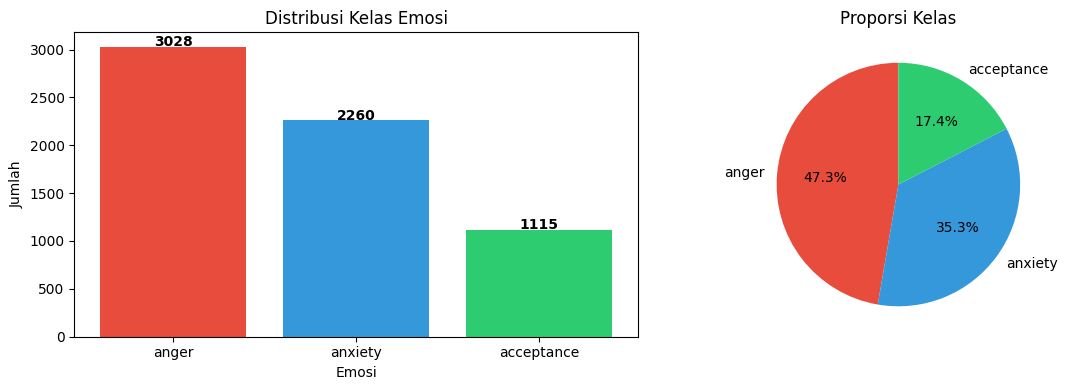

predicted_emotion
anger         3028
anxiety       2260
acceptance    1115
Name: count, dtype: int64


In [ ]:
 # ── Distribusi Kelas ─────────────────────────────────────────
label_counts = df['predicted_emotion'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(label_counts.index, label_counts.values,
            color=['#e74c3c', '#3498db', '#2ecc71'])
axes[0].set_title('Distribusi Kelas Emosi')
axes[0].set_xlabel('Emosi')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(label_counts.values, labels=label_counts.index,
            autopct='%1.1f%%', colors=['#e74c3c', '#3498db', '#2ecc71'],
            startangle=90)
axes[1].set_title('Proporsi Kelas')

plt.tight_layout()
plt.show()
print(label_counts)

## Split Data

In [ ]:

raw = df['acceptance_prob'] - (df['anger_prob'] + df['anxiety_prob']) / 2
df['healing_score'] = (raw - raw.min()) / (raw.max() - raw.min())

healing_min = float(raw.min())
healing_max = float(raw.max())
print(f"healing_score range setelah normalisasi: {df['healing_score'].min():.4f} – {df['healing_score'].max():.4f}")


with open(os.path.join(ARTIFACTS_DIR, 'healing_scaler.pkl'), 'wb') as f:
    pickle.dump({'min': healing_min, 'max': healing_max}, f)
print("✓ Healing scaler disimpan.")

healing_score stats:
count    6403.000000
mean       -0.119553
std         0.311586
min        -0.499975
25%        -0.340240
50%        -0.182088
75%        -0.008402
max         0.997269
Name: healing_score, dtype: float64


,input_clean,input_no_punct,anger_prob,anxiety_prob,acceptance_prob,predicted_emotion,emotion_confidence,input_length,label_length,healing_score
0,i am feeling unloved and unwanted and as if th...,i am feeling unloved and unwanted and as if th...,0.211942,0.211942,0.576117,acceptance,0.576117,21,1,0.364175
1,i am fighting with my mind trying to tell myse...,i am fighting with my mind trying to tell myse...,0.106507,0.786986,0.106507,anxiety,0.786986,22,1,-0.340240
2,i felt i won an argument afterwards i felt mys...,i felt i won an argument afterwards i felt mys...,0.211942,0.211942,0.576117,acceptance,0.576117,21,1,0.364175
3,i felt as if i was fighting a battle that i wa...,i felt as if i was fighting a battle that i wa...,0.045279,0.045279,0.909443,acceptance,0.909443,30,1,0.864164
4,i miss you i miss the chats but it is the any ...,i miss you i miss the chats but it is the any ...,0.114195,0.843795,0.042010,anxiety,0.843795,48,1,-0.436985


In [8]:
X = df['input_clean'].fillna('').astype(str)
y = df['predicted_emotion']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

NUM_CLASSES = len(le.classes_)

print('\nLabel encoding:')
for i, cls in enumerate(le.classes_):
    print(f'  {cls:12s} → {i}')

y_healing = df['healing_score'].values.astype(np.float32)
print(f'\nHealing score — min: {y_healing.min():.4f}, max: {y_healing.max():.4f}, mean: {y_healing.mean():.4f}')

with open(os.path.join(ARTIFACTS_DIR, 'label_encoder.pkl'), 'wb') as f:
    pickle.dump(le, f)
print("✓ Label encoder disimpan.")


Label encoding:
  acceptance   → 0
  anger        → 1
  anxiety      → 2

Healing score — min: -0.5000, max: 0.9973, mean: -0.1196
✓ Label encoder disimpan.


In [9]:
X_train, X_temp, y_train, y_temp, yh_train, yh_temp = train_test_split(
    X, y_encoded, y_healing,
    test_size=0.2, random_state=RANDOM_SEED, stratify=y_encoded
)

X_val, X_test, y_val, y_test, yh_val, yh_test = train_test_split(
    X_temp, y_temp, yh_temp,
    test_size=0.5, random_state=RANDOM_SEED, stratify=y_temp
)

print(f'\nData split:')
print(f'  Train set : {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)')
print(f'  Val set   : {len(X_val):,} samples ({len(X_val)/len(X)*100:.1f}%)')
print(f'  Test set  : {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)')

print("Distribusi train:", Counter(y_train))
print("Distribusi val:  ", Counter(y_val))
print("Distribusi test: ", Counter(y_test))



Data split:
  Train set : 5,122 samples (80.0%)
  Val set   : 640 samples (10.0%)
  Test set  : 641 samples (10.0%)
Distribusi train: Counter({1: 2422, 2: 1808, 0: 892})
Distribusi val:   Counter({1: 303, 2: 226, 0: 111})
Distribusi test:  Counter({1: 303, 2: 226, 0: 112})


## Tokenisasi dan Padding

In [10]:
tokenizer = Tokenizer(num_words=NUM_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

vocab_size = min(len(tokenizer.word_index) + 1, NUM_WORDS)
print(f'Vocab size (aktual) : {len(tokenizer.word_index):,}')
print(f'Vocab size (capped) : {vocab_size:,}')

def texts_to_padded(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LENGTH, padding='post', truncating='post')

X_train_seq = texts_to_padded(X_train)
X_val_seq   = texts_to_padded(X_val)
X_test_seq  = texts_to_padded(X_test)

print(f'\nShape setelah padding:')
print(f'  Train : {X_train_seq.shape}')
print(f'  Val   : {X_val_seq.shape}')
print(f'  Test  : {X_test_seq.shape}')

with open(os.path.join(ARTIFACTS_DIR, 'tokenizer.pkl'), 'wb') as f:
    pickle.dump(tokenizer, f)
print(" Tokenizer disimpan.")

Vocab size (aktual) : 6,402
Vocab size (capped) : 6,403

Shape setelah padding:
  Train : (5122, 200)
  Val   : (640, 200)
  Test  : (641, 200)
 Tokenizer disimpan.


### Pembuatan Tf.data.dataset

In [11]:
train_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_train_seq, (y_train, yh_train)))
    .shuffle(len(X_train_seq), seed=RANDOM_SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_val_seq, (y_val, yh_val)))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_test_seq, (y_test, yh_test)))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight = {i: w for i, w in enumerate(class_weights_arr)}

print(f"  train_ds : {len(list(train_ds))} batch")
print(f"  val_ds   : {len(list(val_ds))} batch")
print(f"  test_ds  : {len(list(test_ds))} batch")
print(f"\nClass weight: {class_weight}")

  train_ds : 161 batch
  val_ds   : 20 batch
  test_ds  : 21 batch

Class weight: {0: 1.914050822122571, 1: 0.7049270575282136, 2: 0.9443215339233039}


## Modeling

### Custom Layer

In [ ]:
class CustomEmbeddingLayer(tf.keras.layers.Layer):
    def __init__(self, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.vocab_size = vocab_size
        self.embed_dim  = embed_dim

    def build(self, input_shape):
        self.embedding_matrix = self.add_weight(
            name='embedding_matrix',
            shape=(self.vocab_size, self.embed_dim),
            initializer=tf.keras.initializers.TruncatedNormal(stddev=0.02),
            trainable=True
        )
        super().build(input_shape)

    def call(self, token_ids):
        x    = tf.nn.embedding_lookup(self.embedding_matrix, token_ids)
        mask = tf.cast(tf.not_equal(token_ids, 0), tf.float32)
        mask = tf.expand_dims(mask, -1)
        return x * mask

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'vocab_size': self.vocab_size, 'embed_dim': self.embed_dim})
        return cfg


class CustomDenseLayer(tf.keras.layers.Layer):
    def __init__(self, units=32, activation='relu', dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.units        = units
        self.activation   = tf.keras.activations.get(activation)
        self.dropout_rate = dropout_rate

    def build(self, input_shape):
        self.W = self.add_weight(
            name='kernel',
            shape=(input_shape[-1], self.units),
            initializer='glorot_uniform',
            trainable=True
        )
        self.b = self.add_weight(
            name='bias',
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )
        self.dropout = tf.keras.layers.Dropout(self.dropout_rate)
        super().build(input_shape)

    def call(self, inputs, training=False):
        x = tf.matmul(inputs, self.W) + self.b
        x = self.activation(x)
        x = self.dropout(x, training=training)
        return x

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
        'units': self.units,
        'dropout_rate': self.dropout_rate,
        'activation': tf.keras.activations.serialize(self.activation),  
    })
        return cfg


class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self, units=64, **kwargs):
        super().__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        self.W_query = self.add_weight(
            name='W_query',
            shape=(input_shape[-1], self.units),
            initializer='glorot_uniform', trainable=True
        )
        self.W_key = self.add_weight(
            name='W_key',
            shape=(input_shape[-1], self.units),
            initializer='glorot_uniform', trainable=True
        )
        self.V = self.add_weight(
            name='V',
            shape=(self.units, 1),
            initializer='glorot_uniform', trainable=True
        )
        self.b = self.add_weight(
            name='bias',
            shape=(self.units,),
            initializer='zeros', trainable=True
        )
        super().build(input_shape)

    def call(self, inputs, mask=None):
        query   = tf.tanh(tf.matmul(inputs, self.W_query) + self.b)
        key     = tf.tanh(tf.matmul(inputs, self.W_key))
        score   = tf.matmul(query + key, self.V)          

      
        if mask is not None:
            mask   = tf.cast(mask, tf.float32)
            mask   = tf.expand_dims(mask, -1)             
            score  = score + (1.0 - mask) * -1e9         

        weights = tf.nn.softmax(score, axis=1)
        context = tf.reduce_sum(inputs * weights, axis=1)
        return context

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'units': self.units})
        return cfg


class CustomConv1DLayer(tf.keras.layers.Layer):
    def __init__(self, filters=128, kernel_size=5,
                 activation='relu', dropout_rate=0.3, **kwargs):
        super().__init__(**kwargs)
        self.filters      = filters
        self.kernel_size  = kernel_size
        self.activation   = tf.keras.activations.get(activation)
        self.dropout_rate = dropout_rate

    def build(self, input_shape):
        self.conv = tf.keras.layers.Conv1D(
            filters=self.filters,
            kernel_size=self.kernel_size,
            padding='same',
            use_bias=False
        )
        self.bn      = tf.keras.layers.BatchNormalization()
        self.dropout = tf.keras.layers.Dropout(self.dropout_rate)
        super().build(input_shape)

    def call(self, inputs, training=False):
        x = self.conv(inputs)
        x = self.bn(x, training=training)
        x = self.activation(x)
        x = self.dropout(x, training=training)
        return x

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            'filters':      self.filters,
            'kernel_size':  self.kernel_size,
            'dropout_rate': self.dropout_rate
        })
        return cfg

### Custom LossFN

In [ ]:
class CustomLossFunction(tf.keras.losses.Loss):

    def __init__(self, mse_weight=0.01, **kwargs):
        super().__init__(**kwargs)
        self.mse_weight = mse_weight

    def call(self, y_true, y_pred):
        ce_loss = tf.keras.losses.sparse_categorical_crossentropy(
            y_true, y_pred, from_logits=False
        )
        ce_loss = tf.reduce_mean(ce_loss)

        y_true_onehot = tf.one_hot(
            tf.cast(y_true, tf.int32),
            depth=tf.shape(y_pred)[-1]
        )
        mse_loss = tf.reduce_mean(tf.square(y_true_onehot - y_pred))

        return ce_loss + self.mse_weight * mse_loss

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'mse_weight': self.mse_weight})
        return cfg


class MultiOutputLoss(tf.keras.losses.Loss):
    def __init__(self, emotion_weight=0.7, healing_weight=0.3,
                 mse_weight=0.01, huber_delta=0.5, **kwargs):
        super().__init__(**kwargs)
        self.emotion_weight = emotion_weight
        self.healing_weight = healing_weight
        self.mse_weight     = mse_weight
        self.huber_delta    = huber_delta
        self._emotion_loss  = CustomLossFunction(mse_weight=mse_weight)
        self._huber         = tf.keras.losses.Huber(delta=huber_delta)

    def call(self, y_true, y_pred):
        y_emotion,    y_healing    = y_true
        pred_emotion, pred_healing = y_pred

        loss_emotion = self._emotion_loss(y_emotion, pred_emotion)
        loss_healing = self._huber(
            tf.expand_dims(y_healing, -1),
            pred_healing
        )
        return self.emotion_weight * loss_emotion + self.healing_weight * loss_healing

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            'emotion_weight': self.emotion_weight,
            'healing_weight': self.healing_weight,
            'mse_weight':     self.mse_weight,
            'huber_delta':    self.huber_delta,
        })
        return cfg


class FocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=0.25, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        ce    = tf.keras.losses.sparse_categorical_crossentropy(
            y_true, y_pred, from_logits=False
        )
        pt    = tf.exp(-ce)
        focal = self.alpha * tf.pow(1.0 - pt, self.gamma) * ce
        return tf.reduce_mean(focal)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'gamma': self.gamma, 'alpha': self.alpha})
        return cfg


class LabelSmoothingLoss(tf.keras.losses.Loss):
    def __init__(self, num_classes, smoothing=0.1, **kwargs):
        super().__init__(**kwargs)
        self.num_classes = num_classes
        self.smoothing   = smoothing

    def call(self, y_true, y_pred):
        y_true_onehot = tf.one_hot(
            tf.cast(y_true, tf.int32),
            depth=self.num_classes
        )
        smooth_labels = (
            y_true_onehot * (1.0 - self.smoothing) +
            (self.smoothing / self.num_classes)
        )
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
        loss   = -tf.reduce_sum(smooth_labels * tf.math.log(y_pred), axis=-1)
        return tf.reduce_mean(loss)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'num_classes': self.num_classes, 'smoothing': self.smoothing})
        return cfg


### Custom CallBack


In [ ]:
class CustomEarlyStopping(tf.keras.callbacks.Callback):
    """Early stopping + otomatis restore bobot terbaik saat berhenti."""
    def __init__(self, patience=5, min_delta=0.001, restore_best_weights=True):
        super().__init__()
        self.patience             = patience
        self.min_delta            = min_delta
        self.restore_best_weights = restore_best_weights
        self.wait                 = 0
        self.best_loss            = np.inf
        self.best_weights         = None  

    def on_train_begin(self, logs=None):
        self.wait         = 0
        self.best_loss    = np.inf
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        current = logs.get('val_loss')
        if current is None:
            return
        if current < self.best_loss - self.min_delta:
            self.best_loss    = current
            self.wait         = 0
            if self.restore_best_weights:
                self.best_weights = self.model.get_weights()  
        else:
            self.wait += 1
            if self.wait >= self.patience:
                print(f"\n[EarlyStopping] Berhenti di epoch {epoch+1} "
                      f"— val_loss tidak membaik selama {self.patience} epoch.")
                if self.restore_best_weights and self.best_weights is not None:
                    self.model.set_weights(self.best_weights)   
                    print(f"[EarlyStopping] ✓ Bobot dikembalikan ke val_loss={self.best_loss:.4f}")
                self.model.stop_training = True


class StopAtAccuracy(tf.keras.callbacks.Callback):

    def __init__(self, target_acc=0.95):
        super().__init__()
        self.target_acc = target_acc

    def on_epoch_end(self, epoch, logs=None):
        acc = logs.get('accuracy')
        if acc is not None and acc >= self.target_acc:
            print(f"\n[StopAtAccuracy] Target {self.target_acc:.0%} "
                  f"tercapai di epoch {epoch+1} (acc={acc:.4f})")
            self.model.stop_training = True


class CustomModelCheckpoint(tf.keras.callbacks.Callback):

    def __init__(self, filepath, monitor='val_loss', save_best_only=True):
        super().__init__()
        self.filepath       = filepath
        self.monitor        = monitor
        self.save_best_only = save_best_only
        self.best = np.inf if 'loss' in monitor else -np.inf

    def on_epoch_end(self, epoch, logs=None):
        current = logs.get(self.monitor)
        if current is None:
            return
        is_better = (
            current < self.best if 'loss' in self.monitor
            else current > self.best
        )
        if not self.save_best_only or is_better:
            print(f"\n[Checkpoint] Simpan model → {self.filepath} "
                  f"({self.monitor}={current:.4f})")
            self.model.save(self.filepath)
            self.best = current


class CustomTensorBoard(tf.keras.callbacks.TensorBoard):

    def __init__(self, log_dir=None, **kwargs):
        log_dir = log_dir or LOG_DIR
        super().__init__(log_dir=log_dir, **kwargs)

    def on_epoch_end(self, epoch, logs=None):
        super().on_epoch_end(epoch, logs)
        if logs:
            print(f"  [TB] Epoch {epoch+1:03d} — "
                  f"loss: {logs.get('loss', 0):.4f}  "
                  f"acc: {logs.get('accuracy', 0):.4f}  "
                  f"val_loss: {logs.get('val_loss', 0):.4f}  "
                  f"val_acc: {logs.get('val_accuracy', 0):.4f}")


class CustomLearningRateScheduler(tf.keras.callbacks.Callback):

    def __init__(self, optimizer, initial_lr=0.001, decay_factor=0.5, step_size=5):
        super().__init__()
        self.optimizer    = optimizer 
        self.initial_lr   = initial_lr
        self.decay_factor = decay_factor
        self.step_size    = step_size

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.step_size == 0:
            new_lr = self.initial_lr * (
                self.decay_factor ** ((epoch + 1) // self.step_size)
            )
            self.optimizer.learning_rate.assign(new_lr)
            print(f"\n[LRScheduler] Epoch {epoch+1} — LR → {new_lr:.6f}")


class TrainingSummaryLogger(tf.keras.callbacks.Callback):

    def __init__(self, save_path=None):
        super().__init__()
        self.save_path  = save_path
        self.start_time = None

    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        # pakai getattr agar aman di custom training loop
        params = getattr(self, 'params', None)
        total_batches = params.get('steps', '?') if params else '?'
        print(f"\n[SummaryLogger] Training dimulai — "
              f"{total_batches} batch/epoch\n")

    def on_train_end(self, logs=None):
        elapsed  = time.time() - self.start_time
        avg_loss = logs.get('loss', 'N/A') if logs else 'N/A'
        print(f"\n[SummaryLogger] Selesai dalam {elapsed:.1f} detik")
        print(f"[SummaryLogger] Loss akhir : {avg_loss}")
        if self.save_path:
            self.model.save(self.save_path)
            print(f"[SummaryLogger] Model disimpan → {self.save_path}")


class OverfittingDetector(tf.keras.callbacks.Callback):

    def __init__(self, threshold=0.15):
        super().__init__()
        self.threshold = threshold

    def on_epoch_end(self, epoch, logs=None):
        train_loss = logs.get('loss', 0)
        val_loss   = logs.get('val_loss', 0)
        gap        = val_loss - train_loss
        if gap > self.threshold:
            print(f"\n[OverfittingDetector] Epoch {epoch+1} — "
                  f"gap={gap:.4f} "
                  f"(train={train_loss:.4f}, val={val_loss:.4f})")



### Custom TrainLOOp

In [ ]:
class customTrainingLoop:
    def __init__(
        self,
        model,
        model_name,
        optimizer,
        loss_fn,
        log_dir      = None,
        class_weight = None,
        callbacks    = None,
    ):
        self.model        = model
        self.model_name   = model_name
        self.optimizer    = optimizer
        self.loss_fn      = loss_fn
        self.log_dir      = log_dir or LOG_DIR
        self.class_weight = class_weight
        self.callbacks    = callbacks or []

        self.history = {
            'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': [],
            'mae': [], 'val_mae': [],
        }

        self.best_val_loss   = np.inf
        self.checkpoint_path = os.path.join(OUTPUT_DIR, f'{self.model_name}_best.keras')

        self.train_writer = tf.summary.create_file_writer(
            os.path.join(self.log_dir, self.model_name, 'train')
        )
        self.val_writer = tf.summary.create_file_writer(
            os.path.join(self.log_dir, self.model_name, 'val')
        )

        self.train_loss_metric = tf.keras.metrics.Mean(name='train_loss')
        self.train_acc_metric  = tf.keras.metrics.SparseCategoricalAccuracy(name='train_acc')
        self.train_mae_metric  = tf.keras.metrics.MeanAbsoluteError(name='train_mae')
        self.val_loss_metric   = tf.keras.metrics.Mean(name='val_loss')
        self.val_acc_metric    = tf.keras.metrics.SparseCategoricalAccuracy(name='val_acc')
        self.val_mae_metric    = tf.keras.metrics.MeanAbsoluteError(name='val_mae')


   
    @tf.function
    def _train_step(self, X_batch, y_emotion, y_healing):
        with tf.GradientTape() as tape:
            pred_emotion, pred_healing = self.model(X_batch, training=True)

            
            ce_loss = tf.keras.losses.sparse_categorical_crossentropy(
                y_emotion, pred_emotion, from_logits=False
            )  

            if self.class_weight is not None:
                cw = tf.constant(list(self.class_weight.values()), dtype=tf.float32)
                sample_weights = tf.gather(cw, tf.cast(y_emotion, tf.int32))
                ce_loss = ce_loss * sample_weights  

            emotion_loss = tf.reduce_mean(ce_loss)

           
            huber = tf.keras.losses.Huber(delta=0.5)
            healing_loss = huber(tf.expand_dims(y_healing, -1), pred_healing)

            loss = 0.7 * emotion_loss + 0.3 * healing_loss

        grads = tape.gradient(loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.model.trainable_variables))
        self.train_loss_metric.update_state(loss)
        self.train_acc_metric.update_state(y_emotion, pred_emotion)
        self.train_mae_metric.update_state(tf.expand_dims(y_healing, -1), pred_healing)


    @tf.function
    def _val_step(self, X_batch, y_emotion, y_healing):
        pred_emotion, pred_healing = self.model(X_batch, training=False)
        loss = self.loss_fn(           
            (y_emotion, y_healing),
            (pred_emotion, pred_healing)
        )
        self.val_loss_metric.update_state(loss)
        self.val_acc_metric.update_state(y_emotion, pred_emotion)
        self.val_mae_metric.update_state(tf.expand_dims(y_healing, -1), pred_healing)


    def fit(self, train_ds, val_ds, epochs):
        print(f"\n{'═'*60}")
        print(f"  Model     : {self.model_name}")
        print(f"  Epochs    : {epochs}")
        print(f"  Optimizer : {self.optimizer.__class__.__name__}")
        print(f"  Loss      : {self.loss_fn.__class__.__name__}")
        print(f"  LR        : {float(self.optimizer.learning_rate):.6f}")
        print(f"  Callbacks : {[c.__class__.__name__ for c in self.callbacks]}")
        print(f"{'═'*60}\n")

        for cb in self.callbacks:
            cb.model = self.model
        for cb in self.callbacks:
            if hasattr(cb, 'on_train_begin'):
                cb.on_train_begin(logs={})

        self.total_start = time.time()
        t_loss = 0

        for epoch in range(epochs):
            epoch_start = time.time()

            for X_batch, (y_emotion, y_healing) in train_ds:
                self._train_step(X_batch, y_emotion, y_healing)

            for X_batch, (y_emotion, y_healing) in val_ds:
                self._val_step(X_batch, y_emotion, y_healing)

            t_loss  = self.train_loss_metric.result().numpy()
            t_acc   = self.train_acc_metric.result().numpy()
            t_mae   = self.train_mae_metric.result().numpy()
            v_loss  = self.val_loss_metric.result().numpy()
            v_acc   = self.val_acc_metric.result().numpy()
            v_mae   = self.val_mae_metric.result().numpy()
            elapsed = time.time() - epoch_start

            self.history['loss'].append(t_loss)
            self.history['accuracy'].append(t_acc)
            self.history['mae'].append(t_mae)
            self.history['val_loss'].append(v_loss)
            self.history['val_accuracy'].append(v_acc)
            self.history['val_mae'].append(v_mae)

            with self.train_writer.as_default():
                tf.summary.scalar('loss',     t_loss, step=epoch)
                tf.summary.scalar('accuracy', t_acc,  step=epoch)
                tf.summary.scalar('mae',      t_mae,  step=epoch)

            with self.val_writer.as_default():
                tf.summary.scalar('loss',     v_loss, step=epoch)
                tf.summary.scalar('accuracy', v_acc,  step=epoch)
                tf.summary.scalar('mae',      v_mae,  step=epoch)

            print(f"Epoch {epoch+1:03d}/{epochs} ({elapsed:.1f}s) — "
                  f"loss: {t_loss:.4f}  acc: {t_acc:.4f}  mae: {t_mae:.4f}  "
                  f"val_loss: {v_loss:.4f}  val_acc: {v_acc:.4f}  val_mae: {v_mae:.4f}")

            gap = v_loss - t_loss
            if gap > 0.15:
                print(f"Overfitting — gap: {gap:.4f}")

            if v_loss < self.best_val_loss:
                self.best_val_loss = v_loss
                self.model.save(self.checkpoint_path)
                print(f"✓ Best model saved (val_loss={v_loss:.4f})")

            self.train_loss_metric.reset_states()
            self.train_acc_metric.reset_states()
            self.train_mae_metric.reset_states()
            self.val_loss_metric.reset_states()
            self.val_acc_metric.reset_states()
            self.val_mae_metric.reset_states()

            logs = {
                'loss': t_loss, 'accuracy': t_acc, 'mae': t_mae,
                'val_loss': v_loss, 'val_accuracy': v_acc, 'val_mae': v_mae,
            }
            for cb in self.callbacks:
                if hasattr(cb, 'on_epoch_end'):
                    cb.on_epoch_end(epoch, logs=logs)

            if getattr(self.model, 'stop_training', False):
                print(f" Training dihentikan oleh callback di epoch {epoch+1}")
                break

        total_elapsed = time.time() - self.total_start

        for cb in self.callbacks:
            if hasattr(cb, 'on_train_end'):
                cb.on_train_end(logs={'loss': t_loss})

        print(f"\n{'═'*60}")
        print(f"  Selesai       : {self.model_name}")
        print(f"  Total waktu   : {total_elapsed:.1f} detik")
        print(f"  Best val_loss : {self.best_val_loss:.4f}")
        print(f"  Checkpoint    : {self.checkpoint_path}")
        print(f"{'═'*60}\n")


    def evaluate(self, test_ds, y_test, yh_test, le):
        print(f"\n{'─'*60}")
        print(f"  Evaluasi : {self.model_name}")
        print(f"{'─'*60}")

        y_pred_emotion_list = []
        y_pred_healing_list = []

        for X_batch, _ in test_ds:
            pred_e, pred_h = self.model(X_batch, training=False)
            y_pred_emotion_list.append(pred_e.numpy())
            y_pred_healing_list.append(pred_h.numpy())

        y_pred_emotion_probs = np.concatenate(y_pred_emotion_list, axis=0)
        y_pred_healing       = np.concatenate(y_pred_healing_list, axis=0).flatten()
        y_pred_emotion       = np.argmax(y_pred_emotion_probs, axis=1)

        acc      = accuracy_score(y_test, y_pred_emotion)
        f1_macro = f1_score(y_test, y_pred_emotion, average='macro')
        f1_w     = f1_score(y_test, y_pred_emotion, average='weighted')
        mae      = np.mean(np.abs(yh_test - y_pred_healing))

        print(f"  Accuracy   : {acc:.4f}  {'✓' if acc >= 0.85 else '✗'} target > 0.85")
        print(f"  F1 Macro   : {f1_macro:.4f}")
        print(f"  F1 Weighted: {f1_w:.4f}")
        print(f"  MAE Healing: {mae:.4f}  {'✓ < 0.2' if mae < 0.2 else '✗ > 0.2'}")
        print(f"\n{classification_report(y_test, y_pred_emotion, target_names=le.classes_)}")

        cm = confusion_matrix(y_test, y_pred_emotion)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=le.classes_, yticklabels=le.classes_)
        plt.title(f'Confusion Matrix — {self.model_name}')
        plt.ylabel('True'); plt.xlabel('Predicted')
        plt.tight_layout(); plt.show()

        return {
            'accuracy':    acc,
            'f1_macro':    f1_macro,
            'f1_weighted': f1_w,
            'mae_healing': mae,
        }


    def plot_history(self):
        epochs = range(1, len(self.history['loss']) + 1)

        fig, axes = plt.subplots(1, 3, figsize=(18, 4))
        fig.suptitle(f'Training History — {self.model_name}', fontsize=13)

        axes[0].plot(epochs, self.history['loss'],     label='Train Loss')
        axes[0].plot(epochs, self.history['val_loss'], label='Val Loss')
        axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

        axes[1].plot(epochs, self.history['accuracy'],     label='Train Acc')
        axes[1].plot(epochs, self.history['val_accuracy'], label='Val Acc')
        axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

        axes[2].plot(epochs, self.history['mae'],     label='Train MAE')
        axes[2].plot(epochs, self.history['val_mae'], label='Val MAE')
        axes[2].set_title('MAE Healing Score'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

        plt.tight_layout(); plt.show()


    def predict(self, text, tokenizer, le, max_length=MAX_LENGTH):
        seq    = tokenizer.texts_to_sequences([text])
        padded = pad_sequences(seq, maxlen=max_length, padding='post', truncating='post')
        pred_e, pred_h = self.model.predict(padded, verbose=0)
        probs  = pred_e[0]
        idx    = np.argmax(probs)

        print(f"  Input         : {text}")
        print(f"  Emosi         : {le.classes_[idx]} ({probs[idx]:.2%})")
        print(f"  Healing Score : {float(pred_h[0][0]):.4f}")
        print(f"  Semua emosi   : { {le.classes_[i]: f'{p:.2%}' for i, p in enumerate(probs)} }")

        return le.classes_[idx], probs[idx], float(pred_h[0][0])



### Model Function

In [ ]:
def model_LSTM():
    inputs = tf.keras.Input(shape=(MAX_LENGTH,), dtype=tf.int32, name='input')
    x      = CustomEmbeddingLayer(vocab_size, EMBED_DIM, name='custom_embedding')(inputs)
    x      = LSTM(128, return_sequences=True, name='lstm_1')(x)
    x      = Dropout(0.4, name='dropout_1')(x)
    x      = LSTM(64, name='lstm_2')(x)
    x      = Dropout(0.4, name='dropout_2')(x)
    shared = CustomDenseLayer(64, activation='relu', dropout_rate=0.3, name='custom_dense')(x)

    out_emotion = Dense(NUM_CLASSES, activation='softmax', name='emotion_output')(shared)
    out_healing = Dense(1, activation='linear', name='healing_output')(shared)

    return tf.keras.Model(inputs=inputs, outputs=(out_emotion, out_healing), name='LSTM')


def model_GRU():
    inputs = tf.keras.Input(shape=(MAX_LENGTH,), dtype=tf.int32, name='input')
    x      = CustomEmbeddingLayer(vocab_size, EMBED_DIM, name='custom_embedding')(inputs)
    x      = GRU(128, return_sequences=True, name='gru_1')(x)
    x      = Dropout(0.4, name='dropout_1')(x)
    x      = GRU(64, name='gru_2')(x)
    x      = Dropout(0.4, name='dropout_2')(x)
    shared = CustomDenseLayer(64, activation='relu', dropout_rate=0.3, name='custom_dense')(x)

    out_emotion = Dense(NUM_CLASSES, activation='softmax', name='emotion_output')(shared)
    out_healing = Dense(1, activation='linear', name='healing_output')(shared)

    return tf.keras.Model(inputs=inputs, outputs=(out_emotion, out_healing), name='GRU')


def model_CNN():
    inputs = tf.keras.Input(shape=(MAX_LENGTH,), dtype=tf.int32, name='input')
    x      = CustomEmbeddingLayer(vocab_size, EMBED_DIM, name='custom_embedding')(inputs)
    x      = CustomConv1DLayer(128, kernel_size=5, dropout_rate=0.3, name='custom_conv_1')(x)
    x      = CustomConv1DLayer(64,  kernel_size=3, dropout_rate=0.3, name='custom_conv_2')(x)
    x      = GlobalMaxPool1D(name='global_max_pool')(x)
    shared = CustomDenseLayer(64, activation='relu', dropout_rate=0.3, name='custom_dense')(x)

    out_emotion = Dense(NUM_CLASSES, activation='softmax', name='emotion_output')(shared)
    out_healing = Dense(1, activation='linear', name='healing_output')(shared)

    return tf.keras.Model(inputs=inputs, outputs=(out_emotion, out_healing), name='CNN')


def model_BiLSTM():
    inputs = tf.keras.Input(shape=(MAX_LENGTH,), dtype=tf.int32, name='input')
    x      = CustomEmbeddingLayer(vocab_size, EMBED_DIM, name='custom_embedding')(inputs)
    x      = Bidirectional(LSTM(128, return_sequences=True), name='bilstm_1')(x)
    x      = Dropout(0.4, name='dropout_1')(x)
    x      = Bidirectional(LSTM(64, return_sequences=True), name='bilstm_2')(x)
    x      = Dropout(0.4, name='dropout_2')(x)
    x      = AttentionLayer(units=64, name='attention')(x)
    shared = CustomDenseLayer(64, activation='relu', dropout_rate=0.3, name='custom_dense')(x)

    out_emotion = Dense(NUM_CLASSES, activation='softmax', name='emotion_output')(shared)
    out_healing = Dense(1, activation='linear', name='healing_output')(shared)

    return tf.keras.Model(inputs=inputs, outputs=(out_emotion, out_healing), name='BiLSTM')


def model_BiGRU():
    inputs = tf.keras.Input(shape=(MAX_LENGTH,), dtype=tf.int32, name='input')
    x      = CustomEmbeddingLayer(vocab_size, EMBED_DIM, name='custom_embedding')(inputs)
    x      = Bidirectional(GRU(128, return_sequences=True), name='bigru_1')(x)
    x      = Dropout(0.4, name='dropout_1')(x)
    x      = Bidirectional(GRU(64, return_sequences=True), name='bigru_2')(x)
    x      = Dropout(0.4, name='dropout_2')(x)
    x      = AttentionLayer(units=64, name='attention')(x)
    shared = CustomDenseLayer(64, activation='relu', dropout_rate=0.3, name='custom_dense')(x)

    out_emotion = Dense(NUM_CLASSES, activation='softmax', name='emotion_output')(shared)
    out_healing = Dense(1, activation='linear', name='healing_output')(shared)

    return tf.keras.Model(inputs=inputs, outputs=(out_emotion, out_healing), name='BiGRU')

print("✓ Semua model function siap.")

✓ Semua model function siap.


### Train Model



════════════════════════════════════════════════════════════
  Model     : LSTM
  Epochs    : 50
  Optimizer : Adam
  Loss      : MultiOutputLoss
  LR        : 0.001000
  Callbacks : ['CustomEarlyStopping', 'OverfittingDetector', 'TrainingSummaryLogger', 'CustomLearningRateScheduler', 'CustomModelCheckpoint']
════════════════════════════════════════════════════════════


[SummaryLogger] Training dimulai — ? batch/epoch

Epoch 001/50 (14.2s) — loss: 0.7453  acc: 0.4674  mae: 0.2457  val_loss: 0.7362  val_acc: 0.4734  val_mae: 0.2266
✓ Best model saved (val_loss=0.7362)

[Checkpoint] Simpan model → ./results\LSTM_checkpoint.keras (val_loss=0.7362)
Epoch 002/50 (8.0s) — loss: 0.7407  acc: 0.4740  mae: 0.2308  val_loss: 0.7332  val_acc: 0.4734  val_mae: 0.2125
✓ Best model saved (val_loss=0.7332)

[Checkpoint] Simpan model → ./results\LSTM_checkpoint.keras (val_loss=0.7332)
Epoch 003/50 (7.4s) — loss: 0.7424  acc: 0.4729  mae: 0.2260  val_loss: 0.7319  val_acc: 0.4734  val_mae: 0.2118
✓ 

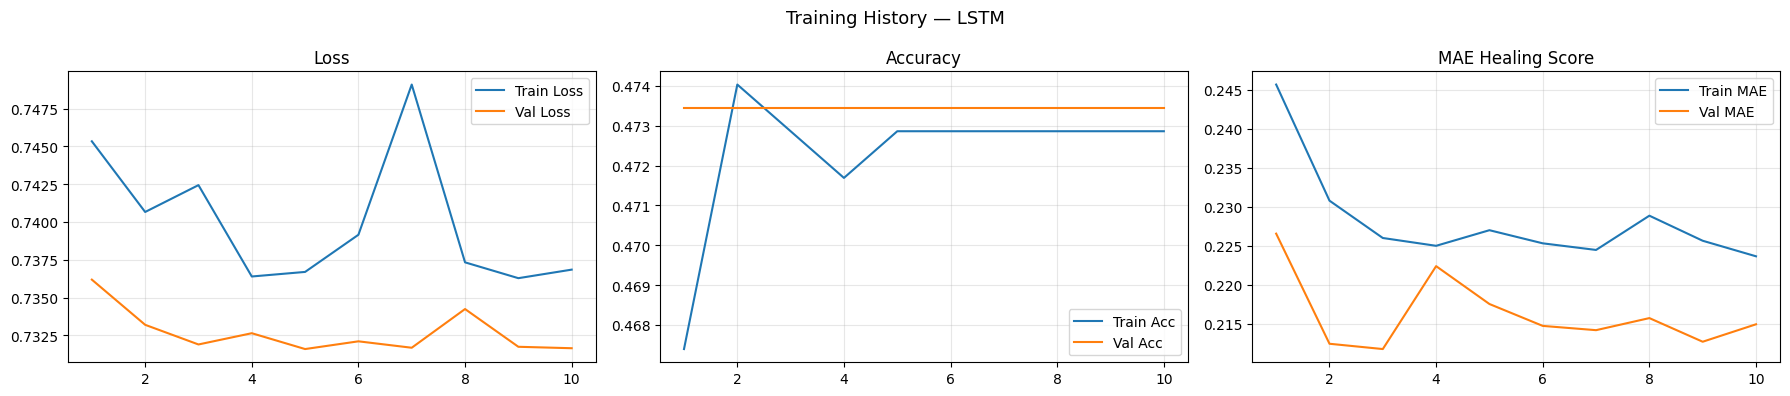

In [19]:

_opt_lstm = tf.keras.optimizers.Adam(learning_rate=0.001)
trainer_LSTM = customTrainingLoop(
    model        = model_LSTM(),
    model_name   = 'LSTM',
    optimizer    = _opt_lstm,
    loss_fn      = MultiOutputLoss(emotion_weight=0.7, healing_weight=0.3),
    log_dir      = LOG_DIR,
    class_weight = class_weight,
    callbacks    = [
        CustomEarlyStopping(patience=7, min_delta=0.001),
        OverfittingDetector(threshold=0.15),
        TrainingSummaryLogger(),
        CustomLearningRateScheduler(optimizer=_opt_lstm, initial_lr=0.001, decay_factor=0.5, step_size=10),
        CustomModelCheckpoint(
            filepath=os.path.join(OUTPUT_DIR, 'LSTM_checkpoint.keras'),
            monitor='val_loss'
        ),
    ],
)
trainer_LSTM.fit(train_ds, val_ds, epochs=EPOCH)
trainer_LSTM.plot_history()


════════════════════════════════════════════════════════════
  Model     : GRU
  Epochs    : 50
  Optimizer : Adam
  Loss      : MultiOutputLoss
  LR        : 0.001000
  Callbacks : ['CustomEarlyStopping', 'OverfittingDetector', 'TrainingSummaryLogger', 'CustomLearningRateScheduler', 'CustomModelCheckpoint']
════════════════════════════════════════════════════════════


[SummaryLogger] Training dimulai — ? batch/epoch

Epoch 001/50 (9.8s) — loss: 0.7427  acc: 0.4684  mae: 0.2478  val_loss: 0.7318  val_acc: 0.4734  val_mae: 0.2137
✓ Best model saved (val_loss=0.7318)

[Checkpoint] Simpan model → ./results\GRU_checkpoint.keras (val_loss=0.7318)
Epoch 002/50 (6.3s) — loss: 0.7438  acc: 0.4727  mae: 0.2348  val_loss: 0.7331  val_acc: 0.4734  val_mae: 0.2204
Epoch 003/50 (6.3s) — loss: 0.7431  acc: 0.4723  mae: 0.2326  val_loss: 0.7319  val_acc: 0.4734  val_mae: 0.2165
Epoch 004/50 (6.3s) — loss: 0.7390  acc: 0.4731  mae: 0.2303  val_loss: 0.7328  val_acc: 0.4734  val_mae: 0.2062
Epoch 005

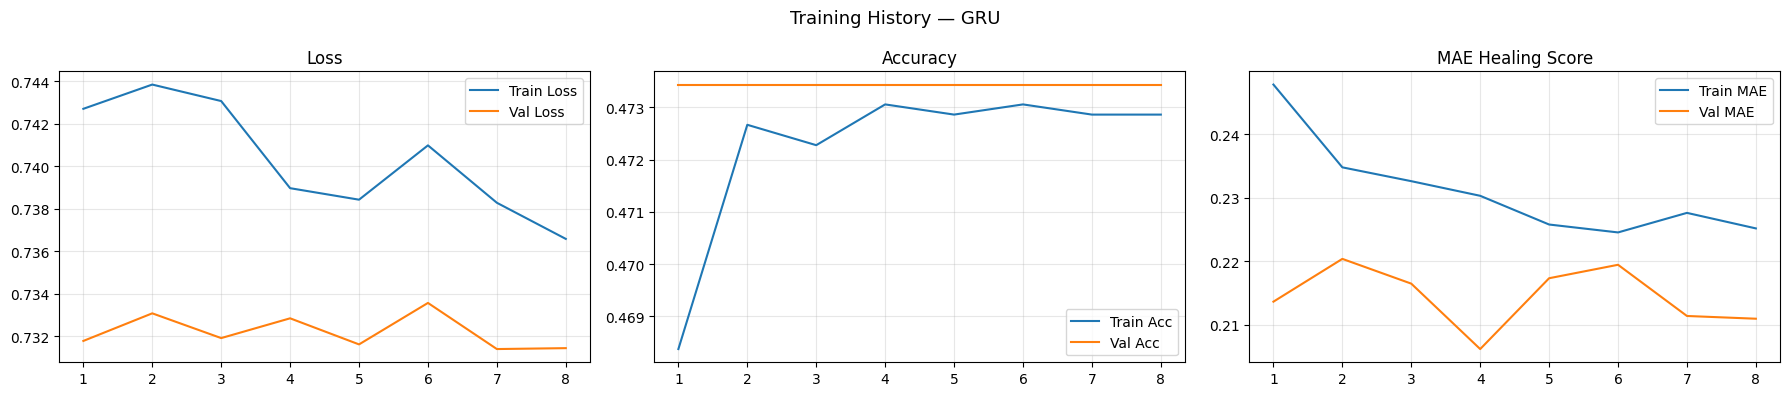

In [20]:
_opt_gru = tf.keras.optimizers.Adam(learning_rate=0.001)
trainer_GRU = customTrainingLoop(
    model        = model_GRU(),
    model_name   = 'GRU',
    optimizer    = _opt_gru,
    loss_fn      = MultiOutputLoss(emotion_weight=0.7, healing_weight=0.3),
    log_dir      = LOG_DIR,
    class_weight = class_weight,
    callbacks    = [
        CustomEarlyStopping(patience=7, min_delta=0.001),
        OverfittingDetector(threshold=0.15),
        TrainingSummaryLogger(),
        CustomLearningRateScheduler(optimizer=_opt_gru, initial_lr=0.001, decay_factor=0.5, step_size=10),
        CustomModelCheckpoint(filepath=os.path.join(OUTPUT_DIR, 'GRU_checkpoint.keras'), monitor='val_loss'),
    ],
)
trainer_GRU.fit(train_ds, val_ds, epochs=EPOCH)
trainer_GRU.plot_history()


════════════════════════════════════════════════════════════
  Model     : CNN
  Epochs    : 50
  Optimizer : Adam
  Loss      : MultiOutputLoss
  LR        : 0.001000
  Callbacks : ['CustomEarlyStopping', 'OverfittingDetector', 'TrainingSummaryLogger', 'CustomLearningRateScheduler', 'CustomModelCheckpoint']
════════════════════════════════════════════════════════════


[SummaryLogger] Training dimulai — ? batch/epoch

Epoch 001/50 (3.2s) — loss: 1.0005  acc: 0.5654  mae: 0.9970  val_loss: 0.7505  val_acc: 0.7578  val_mae: 0.2752
✓ Best model saved (val_loss=0.7505)

[Checkpoint] Simpan model → ./results\CNN_checkpoint.keras (val_loss=0.7505)
Epoch 002/50 (1.4s) — loss: 0.3701  acc: 0.8096  mae: 0.3296  val_loss: 0.6045  val_acc: 0.8703  val_mae: 0.2248
Overfitting — gap: 0.2345
✓ Best model saved (val_loss=0.6045)

[OverfittingDetector] Epoch 2 — gap=0.2345 (train=0.3701, val=0.6045)

[Checkpoint] Simpan model → ./results\CNN_checkpoint.keras (val_loss=0.6045)
Epoch 003/50 (1.4s) — l

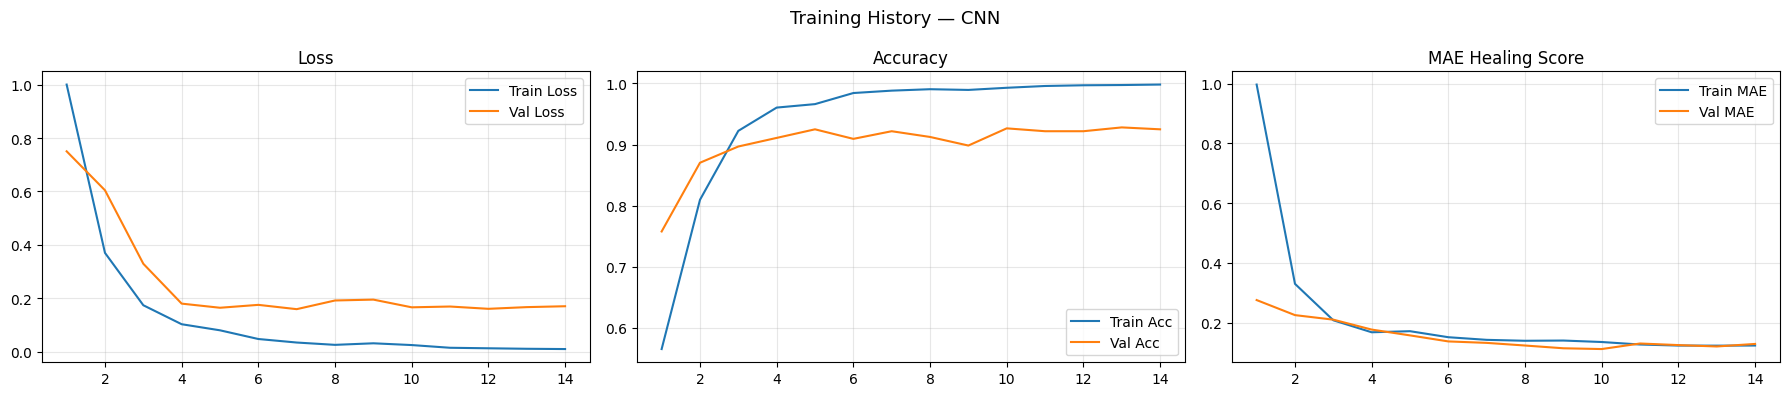

In [21]:
_opt_cnn = tf.keras.optimizers.Adam(learning_rate=0.001)
trainer_CNN = customTrainingLoop(
    model        = model_CNN(),
    model_name   = 'CNN',
    optimizer    = _opt_cnn,
    loss_fn      = MultiOutputLoss(emotion_weight=0.7, healing_weight=0.3),
    log_dir      = LOG_DIR,
    class_weight = class_weight,
    callbacks    = [
        CustomEarlyStopping(patience=7, min_delta=0.001),
        OverfittingDetector(threshold=0.15),
        TrainingSummaryLogger(),
        CustomLearningRateScheduler(optimizer=_opt_cnn, initial_lr=0.001, decay_factor=0.5, step_size=10),
        CustomModelCheckpoint(filepath=os.path.join(OUTPUT_DIR, 'CNN_checkpoint.keras'), monitor='val_loss'),
    ],
)
trainer_CNN.fit(train_ds, val_ds, epochs=EPOCH)
trainer_CNN.plot_history()


════════════════════════════════════════════════════════════
  Model     : BiLSTM
  Epochs    : 50
  Optimizer : Adam
  Loss      : MultiOutputLoss
  LR        : 0.001000
  Callbacks : ['CustomEarlyStopping', 'StopAtAccuracy', 'OverfittingDetector', 'TrainingSummaryLogger', 'CustomLearningRateScheduler', 'CustomModelCheckpoint']
════════════════════════════════════════════════════════════


[SummaryLogger] Training dimulai — ? batch/epoch

Epoch 001/50 (18.0s) — loss: 0.5385  acc: 0.6533  mae: 0.2528  val_loss: 0.2908  val_acc: 0.8828  val_mae: 0.1466
✓ Best model saved (val_loss=0.2908)

[Checkpoint] Simpan model → ./results\BiLSTM_checkpoint.keras (val_loss=0.2908)
Epoch 002/50 (12.3s) — loss: 0.1825  acc: 0.9291  mae: 0.2101  val_loss: 0.2769  val_acc: 0.8891  val_mae: 0.1333
✓ Best model saved (val_loss=0.2769)

[StopAtAccuracy] Target 90% tercapai di epoch 2 (acc=0.9291)

[Checkpoint] Simpan model → ./results\BiLSTM_checkpoint.keras (val_loss=0.2769)
 Training dihentikan oleh cal

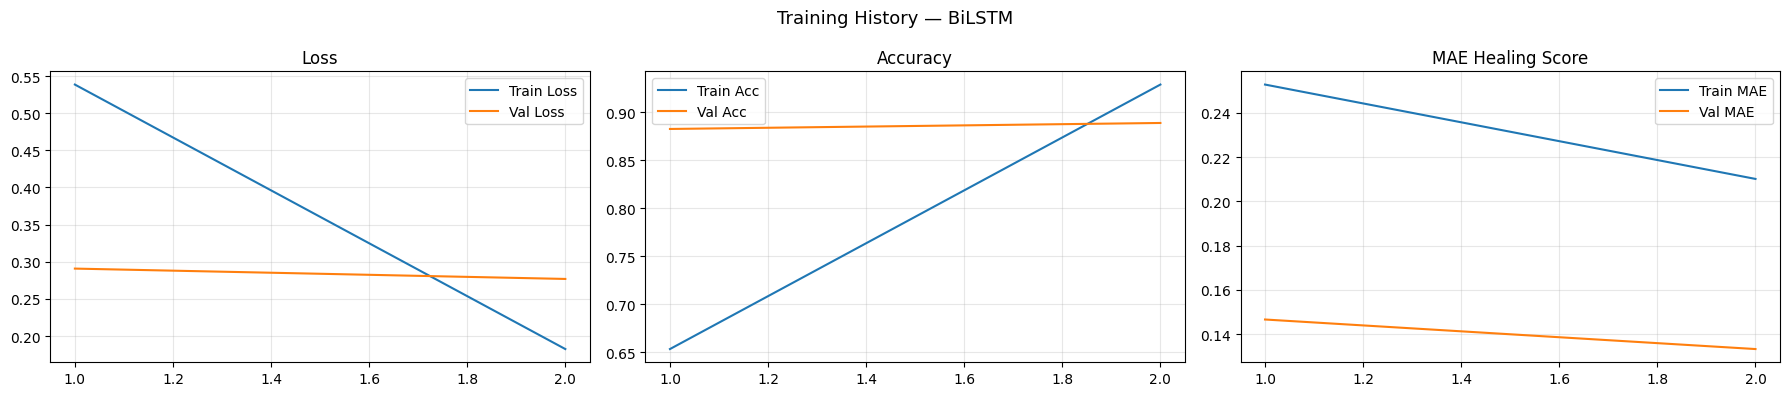

In [22]:
_opt_bilstm = tf.keras.optimizers.Adam(learning_rate=0.001)
trainer_BiLSTM = customTrainingLoop(
    model        = model_BiLSTM(),
    model_name   = 'BiLSTM',
    optimizer    = _opt_bilstm,
    loss_fn      = MultiOutputLoss(emotion_weight=0.7, healing_weight=0.3),
    log_dir      = LOG_DIR,
    class_weight = class_weight,
    callbacks    = [
        CustomEarlyStopping(patience=7, min_delta=0.001),
        StopAtAccuracy(target_acc=0.90),
        OverfittingDetector(threshold=0.15),
        TrainingSummaryLogger(),
        CustomLearningRateScheduler(optimizer=_opt_bilstm, initial_lr=0.001, decay_factor=0.5, step_size=10),
        CustomModelCheckpoint(filepath=os.path.join(OUTPUT_DIR, 'BiLSTM_checkpoint.keras'), monitor='val_loss'),
    ],
)
trainer_BiLSTM.fit(train_ds, val_ds, epochs=EPOCH)
trainer_BiLSTM.plot_history()


════════════════════════════════════════════════════════════
  Model     : BiGRU
  Epochs    : 50
  Optimizer : Adam
  Loss      : MultiOutputLoss
  LR        : 0.001000
  Callbacks : ['CustomEarlyStopping', 'StopAtAccuracy', 'OverfittingDetector', 'TrainingSummaryLogger', 'CustomLearningRateScheduler', 'CustomModelCheckpoint']
════════════════════════════════════════════════════════════


[SummaryLogger] Training dimulai — ? batch/epoch

Epoch 001/50 (15.9s) — loss: 0.5367  acc: 0.6607  mae: 0.2887  val_loss: 0.3210  val_acc: 0.8344  val_mae: 0.1587
✓ Best model saved (val_loss=0.3210)

[Checkpoint] Simpan model → ./results\BiGRU_checkpoint.keras (val_loss=0.3210)
Epoch 002/50 (10.5s) — loss: 0.2198  acc: 0.9047  mae: 0.2405  val_loss: 0.2571  val_acc: 0.8734  val_mae: 0.1275
✓ Best model saved (val_loss=0.2571)

[StopAtAccuracy] Target 90% tercapai di epoch 2 (acc=0.9047)

[Checkpoint] Simpan model → ./results\BiGRU_checkpoint.keras (val_loss=0.2571)
 Training dihentikan oleh callba

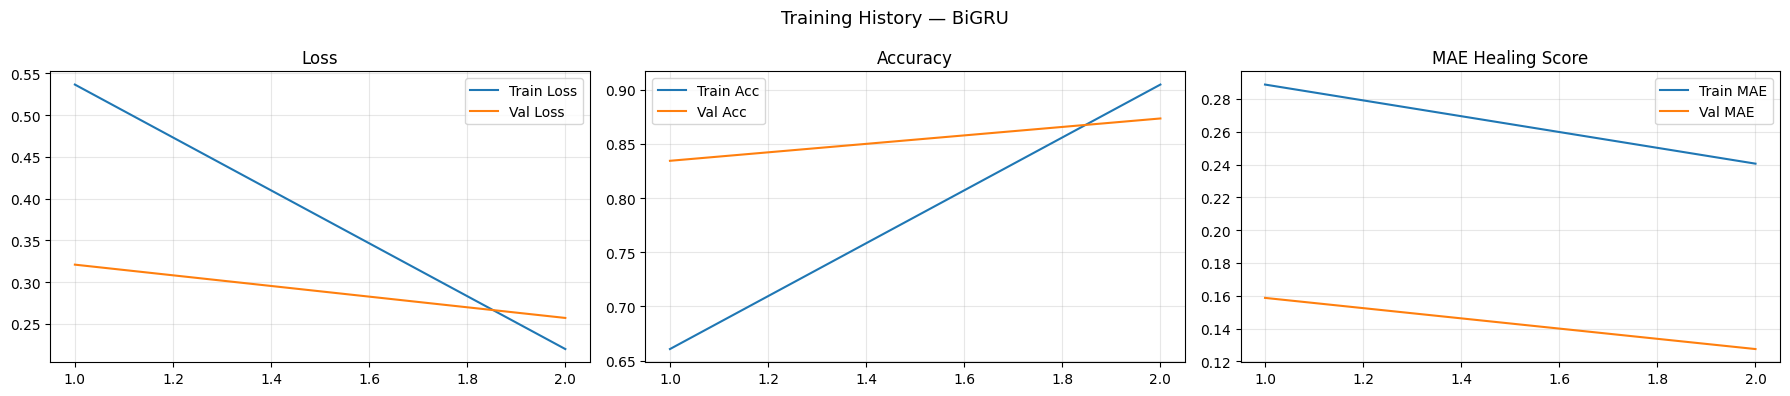

In [23]:
_opt_bigru = tf.keras.optimizers.Adam(learning_rate=0.001)
trainer_BiGRU = customTrainingLoop(
    model        = model_BiGRU(),
    model_name   = 'BiGRU',
    optimizer    = _opt_bigru,
    loss_fn      = MultiOutputLoss(emotion_weight=0.7, healing_weight=0.3),
    log_dir      = LOG_DIR,
    class_weight = class_weight,
    callbacks    = [
        CustomEarlyStopping(patience=7, min_delta=0.001),
        StopAtAccuracy(target_acc=0.90),
        OverfittingDetector(threshold=0.15),
        TrainingSummaryLogger(),
        CustomLearningRateScheduler(optimizer=_opt_bigru, initial_lr=0.001, decay_factor=0.5, step_size=10),
        CustomModelCheckpoint(filepath=os.path.join(OUTPUT_DIR, 'BiGRU_checkpoint.keras'), monitor='val_loss'),
    ],
)
trainer_BiGRU.fit(train_ds, val_ds, epochs=EPOCH)
trainer_BiGRU.plot_history()

### Transfer learning

In [24]:
BERT_MODEL_NAME = 'bert-base-uncased'
BERT_MAX_LENGTH = 128

bert_tokenizer = BertTokenizer.from_pretrained(BERT_MODEL_NAME)

def bert_encode(texts, tokenizer, max_length):
    encoded = tokenizer(
        list(texts),
        max_length     = max_length,
        padding        = 'max_length',
        truncation     = True,
        return_tensors = 'tf'
    )
    return (
        encoded['input_ids'],
        encoded['attention_mask'],
        encoded['token_type_ids']
    )

print("Encoding train...")
train_ids, train_mask, train_type = bert_encode(X_train, bert_tokenizer, BERT_MAX_LENGTH)

print("Encoding val...")
val_ids, val_mask, val_type = bert_encode(X_val, bert_tokenizer, BERT_MAX_LENGTH)

print("Encoding test...")
test_ids, test_mask, test_type = bert_encode(X_test, bert_tokenizer, BERT_MAX_LENGTH)

bert_train_ds = (
    tf.data.Dataset
    .from_tensor_slices((
        {
            'input_ids'     : train_ids,
            'attention_mask': train_mask,
            'token_type_ids': train_type,
        },
        (y_train, yh_train)
    ))
    .shuffle(len(y_train), seed=RANDOM_SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

bert_val_ds = (
    tf.data.Dataset
    .from_tensor_slices((
        {
            'input_ids'     : val_ids,
            'attention_mask': val_mask,
            'token_type_ids': val_type,
        },
        (y_val, yh_val)
    ))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

bert_test_ds = (
    tf.data.Dataset
    .from_tensor_slices((
        {
            'input_ids'     : test_ids,
            'attention_mask': test_mask,
            'token_type_ids': test_type,
        },
        (y_test, yh_test)
    ))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("✓ bert_train_ds :", len(list(bert_train_ds)), "batch")
print("✓ bert_val_ds   :", len(list(bert_val_ds)),   "batch")
print("✓ bert_test_ds  :", len(list(bert_test_ds)),  "batch")

Encoding train...
Encoding val...
Encoding test...
✓ bert_train_ds : 161 batch
✓ bert_val_ds   : 20 batch
✓ bert_test_ds  : 21 batch


In [ ]:
def model_BERT():
    input_ids      = tf.keras.Input(shape=(BERT_MAX_LENGTH,), dtype=tf.int32, name='input_ids')
    attention_mask = tf.keras.Input(shape=(BERT_MAX_LENGTH,), dtype=tf.int32, name='attention_mask')
    token_type_ids = tf.keras.Input(shape=(BERT_MAX_LENGTH,), dtype=tf.int32, name='token_type_ids')

    bert_layer = TFBertModel.from_pretrained(BERT_MODEL_NAME, from_pt=False)
    bert_layer.trainable = False  
    bert_outputs = bert_layer(
        {
            'input_ids'      : input_ids,
            'attention_mask' : attention_mask,
            'token_type_ids' : token_type_ids,
        }
    )

    cls_output = bert_outputs.last_hidden_state[:, 0, :] 

    shared = Dense(256, activation='relu', name='shared_dense')(cls_output)
    shared = Dropout(0.3,                  name='shared_dropout')(shared)

    out_emotion = Dense(NUM_CLASSES, activation='softmax', name='emotion_output')(shared)
    out_healing = Dense(1,           activation='linear',  name='healing_output')(shared)

    return tf.keras.Model(
        inputs  = [input_ids, attention_mask, token_type_ids],
        outputs = (out_emotion, out_healing),
        name    = 'BERT'
    )

In [ ]:
class CustomTrainerBERT:
    def __init__(
        self,
        model,
        model_name,
        optimizer,
        loss_fn,
        log_dir      = None,
        class_weight = None,
        callbacks    = None,
    ):
        self.model        = model
        self.model_name   = model_name
        self.optimizer    = optimizer
        self.loss_fn      = loss_fn
        self.log_dir      = log_dir or LOG_DIR
        self.class_weight = class_weight
        self.callbacks    = callbacks or []

        self.history = {
            'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': [],
            'mae': [], 'val_mae': [],
        }

        self.best_val_loss   = np.inf
        self.checkpoint_path = os.path.join(OUTPUT_DIR, f'{model_name}_best.keras')

        self.train_writer = tf.summary.create_file_writer(
            os.path.join(self.log_dir, self.model_name, 'train')
        )
        self.val_writer = tf.summary.create_file_writer(
            os.path.join(self.log_dir, self.model_name, 'val')
        )

        self.train_loss_metric = tf.keras.metrics.Mean(name='train_loss')
        self.train_acc_metric  = tf.keras.metrics.SparseCategoricalAccuracy(name='train_acc')
        self.train_mae_metric  = tf.keras.metrics.MeanAbsoluteError(name='train_mae')
        self.val_loss_metric   = tf.keras.metrics.Mean(name='val_loss')
        self.val_acc_metric    = tf.keras.metrics.SparseCategoricalAccuracy(name='val_acc')
        self.val_mae_metric    = tf.keras.metrics.MeanAbsoluteError(name='val_mae')


    @tf.function
    def _train_step(self, X_batch, y_emotion, y_healing):
        with tf.GradientTape() as tape:
            pred_emotion, pred_healing = self.model(X_batch, training=True)

            
            ce_loss = tf.keras.losses.sparse_categorical_crossentropy(
                y_emotion, pred_emotion, from_logits=False
            )  

            if self.class_weight is not None:
                cw = tf.constant(list(self.class_weight.values()), dtype=tf.float32)
                sample_weights = tf.gather(cw, tf.cast(y_emotion, tf.int32))
                ce_loss = ce_loss * sample_weights  

            emotion_loss = tf.reduce_mean(ce_loss)

           
            huber = tf.keras.losses.Huber(delta=0.5)
            healing_loss = huber(tf.expand_dims(y_healing, -1), pred_healing)

            loss = 0.7 * emotion_loss + 0.3 * healing_loss

        grads = tape.gradient(loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.model.trainable_variables))
        self.train_loss_metric.update_state(loss)
        self.train_acc_metric.update_state(y_emotion, pred_emotion)
        self.train_mae_metric.update_state(tf.expand_dims(y_healing, -1), pred_healing)

    @tf.function
    def _val_step(self, X_batch, y_emotion, y_healing):
        pred_emotion, pred_healing = self.model(X_batch, training=False)
        loss = self.loss_fn(           
            (y_emotion, y_healing),
            (pred_emotion, pred_healing)
        )
        self.val_loss_metric.update_state(loss)
        self.val_acc_metric.update_state(y_emotion, pred_emotion)
        self.val_mae_metric.update_state(tf.expand_dims(y_healing, -1), pred_healing)


    def fit(self, train_ds, val_ds, epochs):
        print(f"\n{'═'*60}")
        print(f"  Model     : {self.model_name}")
        print(f"  Epochs    : {epochs}")
        print(f"  Optimizer : {self.optimizer.__class__.__name__}")
        print(f"  Loss      : {self.loss_fn.__class__.__name__}")
        print(f"  LR        : {float(self.optimizer.learning_rate):.6f}")
        print(f"  Callbacks : {[c.__class__.__name__ for c in self.callbacks]}")
        print(f"{'═'*60}\n")

        for cb in self.callbacks:
            cb.model = self.model
        for cb in self.callbacks:
            if hasattr(cb, 'on_train_begin'):
                cb.on_train_begin(logs={})

        self.total_start = time.time()
        t_loss = 0

        for epoch in range(epochs):
            epoch_start = time.time()

            for X_batch, (y_emotion, y_healing) in train_ds:
                self._train_step(X_batch, y_emotion, y_healing)

            for X_batch, (y_emotion, y_healing) in val_ds:
                self._val_step(X_batch, y_emotion, y_healing)

            t_loss  = self.train_loss_metric.result().numpy()
            t_acc   = self.train_acc_metric.result().numpy()
            t_mae   = self.train_mae_metric.result().numpy()
            v_loss  = self.val_loss_metric.result().numpy()
            v_acc   = self.val_acc_metric.result().numpy()
            v_mae   = self.val_mae_metric.result().numpy()
            elapsed = time.time() - epoch_start

            self.history['loss'].append(t_loss)
            self.history['accuracy'].append(t_acc)
            self.history['mae'].append(t_mae)
            self.history['val_loss'].append(v_loss)
            self.history['val_accuracy'].append(v_acc)
            self.history['val_mae'].append(v_mae)

            with self.train_writer.as_default():
                tf.summary.scalar('loss',     t_loss, step=epoch)
                tf.summary.scalar('accuracy', t_acc,  step=epoch)
                tf.summary.scalar('mae',      t_mae,  step=epoch)

            with self.val_writer.as_default():
                tf.summary.scalar('loss',     v_loss, step=epoch)
                tf.summary.scalar('accuracy', v_acc,  step=epoch)
                tf.summary.scalar('mae',      v_mae,  step=epoch)

            print(f"Epoch {epoch+1:03d}/{epochs} ({elapsed:.1f}s) — "
                  f"loss: {t_loss:.4f}  acc: {t_acc:.4f}  mae: {t_mae:.4f}  "
                  f"val_loss: {v_loss:.4f}  val_acc: {v_acc:.4f}  val_mae: {v_mae:.4f}")

            gap = v_loss - t_loss
            if gap > 0.15:
                print(f" Overfitting — gap: {gap:.4f}")

            if v_loss < self.best_val_loss:
                self.best_val_loss = v_loss
                self.model.save(self.checkpoint_path)
                print(f"✓ Best model saved (val_loss={v_loss:.4f})")

            self.train_loss_metric.reset_states()
            self.train_acc_metric.reset_states()
            self.train_mae_metric.reset_states()
            self.val_loss_metric.reset_states()
            self.val_acc_metric.reset_states()
            self.val_mae_metric.reset_states()

            logs = {
                'loss': t_loss, 'accuracy': t_acc, 'mae': t_mae,
                'val_loss': v_loss, 'val_accuracy': v_acc, 'val_mae': v_mae,
            }
            for cb in self.callbacks:
                if hasattr(cb, 'on_epoch_end'):
                    cb.on_epoch_end(epoch, logs=logs)

            if getattr(self.model, 'stop_training', False):
                print(f" Training dihentikan oleh callback di epoch {epoch+1}")
                break

        total_elapsed = time.time() - self.total_start

        for cb in self.callbacks:
            if hasattr(cb, 'on_train_end'):
                cb.on_train_end(logs={'loss': t_loss})

        print(f"\n{'═'*60}")
        print(f"  Selesai       : {self.model_name}")
        print(f"  Total waktu   : {total_elapsed:.1f} detik")
        print(f"  Best val_loss : {self.best_val_loss:.4f}")
        print(f"  Checkpoint    : {self.checkpoint_path}")
        print(f"{'═'*60}\n")


    def evaluate(self, test_ds, y_test, yh_test, le):
        print(f"\n{'─'*60}")
        print(f"  Evaluasi : {self.model_name}")
        print(f"{'─'*60}")

        y_pred_emotion_list = []
        y_pred_healing_list = []

        for X_batch, _ in test_ds:
            pred_e, pred_h = self.model(X_batch, training=False)
            y_pred_emotion_list.append(pred_e.numpy())
            y_pred_healing_list.append(pred_h.numpy())

        y_pred_emotion_probs = np.concatenate(y_pred_emotion_list, axis=0)
        y_pred_healing       = np.concatenate(y_pred_healing_list, axis=0).flatten()
        y_pred_emotion       = np.argmax(y_pred_emotion_probs, axis=1)

        acc      = accuracy_score(y_test, y_pred_emotion)
        f1_macro = f1_score(y_test, y_pred_emotion, average='macro')
        f1_w     = f1_score(y_test, y_pred_emotion, average='weighted')
        mae      = np.mean(np.abs(yh_test - y_pred_healing))

        print(f"  Accuracy   : {acc:.4f}  {'✓' if acc >= 0.85 else '✗'} target > 0.85")
        print(f"  F1 Macro   : {f1_macro:.4f}")
        print(f"  F1 Weighted: {f1_w:.4f}")
        print(f"  MAE Healing: {mae:.4f}  {'✓ < 0.2' if mae < 0.2 else '✗ > 0.2'}")
        print(f"\n{classification_report(y_test, y_pred_emotion, target_names=le.classes_)}")

        cm = confusion_matrix(y_test, y_pred_emotion)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=le.classes_, yticklabels=le.classes_)
        plt.title(f'Confusion Matrix — {self.model_name}')
        plt.ylabel('True'); plt.xlabel('Predicted')
        plt.tight_layout(); plt.show()

        return {
            'accuracy':    acc,
            'f1_macro':    f1_macro,
            'f1_weighted': f1_w,
            'mae_healing': mae,
        }


    def plot_history(self):
        epochs = range(1, len(self.history['loss']) + 1)

        fig, axes = plt.subplots(1, 3, figsize=(18, 4))
        fig.suptitle(f'Training History — {self.model_name}', fontsize=13)

        axes[0].plot(epochs, self.history['loss'],     label='Train Loss')
        axes[0].plot(epochs, self.history['val_loss'], label='Val Loss')
        axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

        axes[1].plot(epochs, self.history['accuracy'],     label='Train Acc')
        axes[1].plot(epochs, self.history['val_accuracy'], label='Val Acc')
        axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

        axes[2].plot(epochs, self.history['mae'],     label='Train MAE')
        axes[2].plot(epochs, self.history['val_mae'], label='Val MAE')
        axes[2].set_title('MAE Healing Score'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

        plt.tight_layout(); plt.show()


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.dense.bias', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w



════════════════════════════════════════════════════════════
  Model     : BERT
  Epochs    : 10
  Optimizer : Adam
  Loss      : MultiOutputLoss
  LR        : 0.000020
  Callbacks : ['CustomEarlyStopping', 'OverfittingDetector', 'TrainingSummaryLogger', 'CustomLearningRateScheduler', 'CustomModelCheckpoint']
════════════════════════════════════════════════════════════


[SummaryLogger] Training dimulai — ? batch/epoch

Epoch 001/10 (172.2s) — loss: 0.8087  acc: 0.4159  mae: 0.4873  val_loss: 0.7195  val_acc: 0.5125  val_mae: 0.2833
✓ Best model saved (val_loss=0.7195)

[Checkpoint] Simpan model → ./results\BERT_checkpoint.keras (val_loss=0.7195)
Epoch 002/10 (155.5s) — loss: 0.7494  acc: 0.4930  mae: 0.4267  val_loss: 0.6850  val_acc: 0.5734  val_mae: 0.2591
✓ Best model saved (val_loss=0.6850)

[LRScheduler] Epoch 2 — LR → 0.000010

[Checkpoint] Simpan model → ./results\BERT_checkpoint.keras (val_loss=0.6850)
Epoch 003/10 (156.5s) — loss: 0.7359  acc: 0.5143  mae: 0.4007  val_loss:

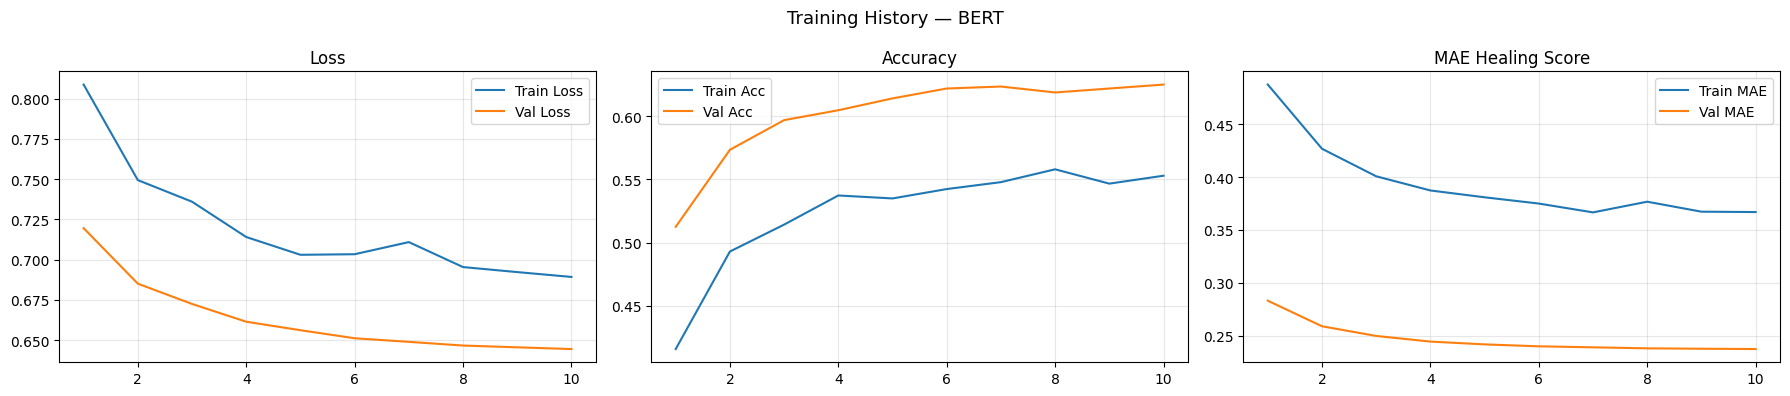

In [27]:
_opt_bert = tf.keras.optimizers.Adam(learning_rate=2e-5, clipnorm=1.0)
trainer_BERT = CustomTrainerBERT(
    model        = model_BERT(),
    model_name   = 'BERT',
    optimizer    = _opt_bert,
    loss_fn      = MultiOutputLoss(emotion_weight=0.7, healing_weight=0.3),
    log_dir      = LOG_DIR,
    class_weight = class_weight,
    callbacks    = [
        CustomEarlyStopping(patience=3, min_delta=0.001),
        OverfittingDetector(threshold=0.15),
        TrainingSummaryLogger(),
        CustomLearningRateScheduler(optimizer=_opt_bert, initial_lr=2e-5, decay_factor=0.5, step_size=2),
        CustomModelCheckpoint(filepath=os.path.join(OUTPUT_DIR, 'BERT_checkpoint.keras'), monitor='val_loss'),
    ],
)
trainer_BERT.fit(bert_train_ds, bert_val_ds, epochs=10)
trainer_BERT.plot_history()

## Evaluasi dan Perbandingan


────────────────────────────────────────────────────────────
  Evaluasi : LSTM
────────────────────────────────────────────────────────────
  Accuracy   : 0.4727  ✗ target > 0.85
  F1 Macro   : 0.2140
  F1 Weighted: 0.3034
  MAE Healing: 0.2235  ✗ > 0.2

              precision    recall  f1-score   support

  acceptance       0.00      0.00      0.00       112
       anger       0.47      1.00      0.64       303
     anxiety       0.00      0.00      0.00       226

    accuracy                           0.47       641
   macro avg       0.16      0.33      0.21       641
weighted avg       0.22      0.47      0.30       641



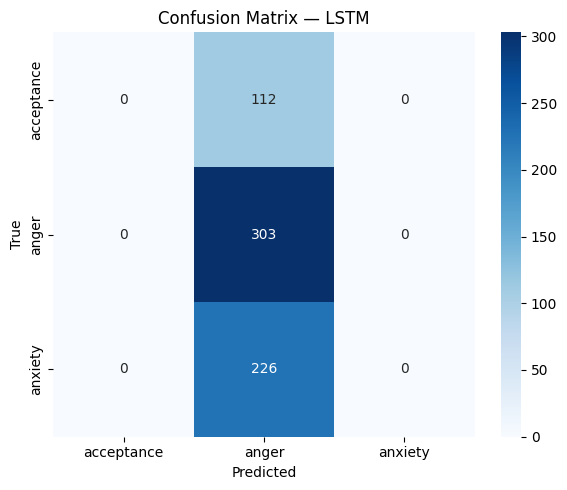


────────────────────────────────────────────────────────────
  Evaluasi : GRU
────────────────────────────────────────────────────────────
  Accuracy   : 0.4727  ✗ target > 0.85
  F1 Macro   : 0.2140
  F1 Weighted: 0.3034
  MAE Healing: 0.2200  ✗ > 0.2

              precision    recall  f1-score   support

  acceptance       0.00      0.00      0.00       112
       anger       0.47      1.00      0.64       303
     anxiety       0.00      0.00      0.00       226

    accuracy                           0.47       641
   macro avg       0.16      0.33      0.21       641
weighted avg       0.22      0.47      0.30       641



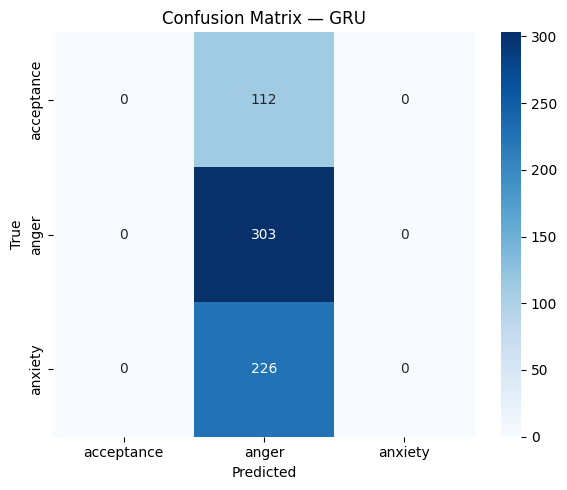


────────────────────────────────────────────────────────────
  Evaluasi : CNN
────────────────────────────────────────────────────────────
  Accuracy   : 0.9579  ✓ target > 0.85
  F1 Macro   : 0.9522
  F1 Weighted: 0.9578
  MAE Healing: 0.1327  ✓ < 0.2

              precision    recall  f1-score   support

  acceptance       0.95      0.92      0.94       112
       anger       0.97      0.98      0.98       303
     anxiety       0.94      0.95      0.95       226

    accuracy                           0.96       641
   macro avg       0.96      0.95      0.95       641
weighted avg       0.96      0.96      0.96       641



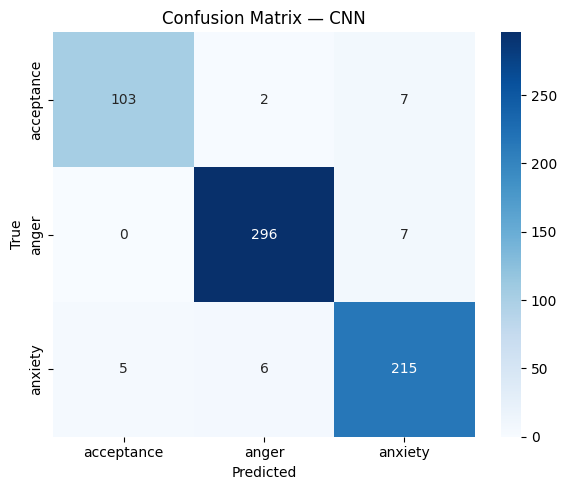


────────────────────────────────────────────────────────────
  Evaluasi : BiLSTM
────────────────────────────────────────────────────────────
  Accuracy   : 0.9282  ✓ target > 0.85
  F1 Macro   : 0.9193
  F1 Weighted: 0.9281
  MAE Healing: 0.1345  ✓ < 0.2

              precision    recall  f1-score   support

  acceptance       0.90      0.88      0.89       112
       anger       0.95      0.96      0.95       303
     anxiety       0.92      0.91      0.91       226

    accuracy                           0.93       641
   macro avg       0.92      0.92      0.92       641
weighted avg       0.93      0.93      0.93       641



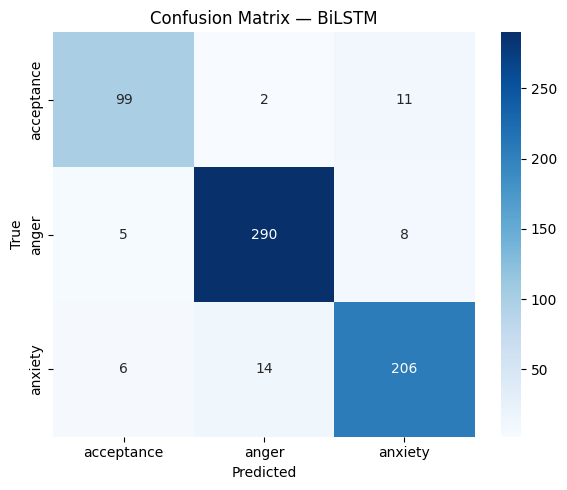


────────────────────────────────────────────────────────────
  Evaluasi : BiGRU
────────────────────────────────────────────────────────────
  Accuracy   : 0.9080  ✓ target > 0.85
  F1 Macro   : 0.8885
  F1 Weighted: 0.9068
  MAE Healing: 0.1258  ✓ < 0.2

              precision    recall  f1-score   support

  acceptance       0.84      0.81      0.83       112
       anger       0.92      0.98      0.95       303
     anxiety       0.92      0.86      0.89       226

    accuracy                           0.91       641
   macro avg       0.89      0.88      0.89       641
weighted avg       0.91      0.91      0.91       641



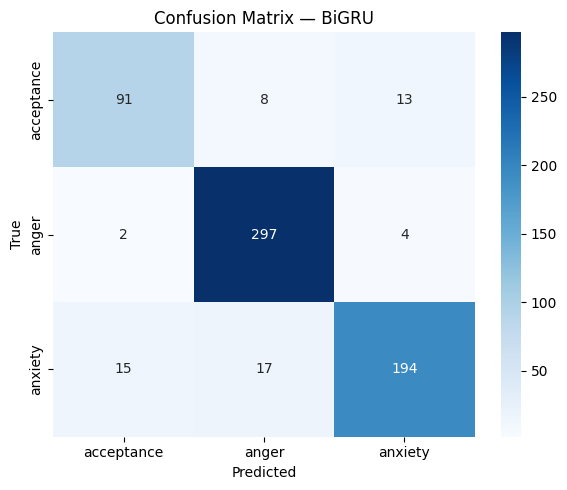


────────────────────────────────────────────────────────────
  Evaluasi : BERT
────────────────────────────────────────────────────────────
  Accuracy   : 0.5959  ✗ target > 0.85
  F1 Macro   : 0.4343
  F1 Weighted: 0.5367
  MAE Healing: 0.2461  ✗ > 0.2

              precision    recall  f1-score   support

  acceptance       0.60      0.03      0.05       112
       anger       0.61      0.87      0.72       303
     anxiety       0.56      0.50      0.53       226

    accuracy                           0.60       641
   macro avg       0.59      0.47      0.43       641
weighted avg       0.59      0.60      0.54       641



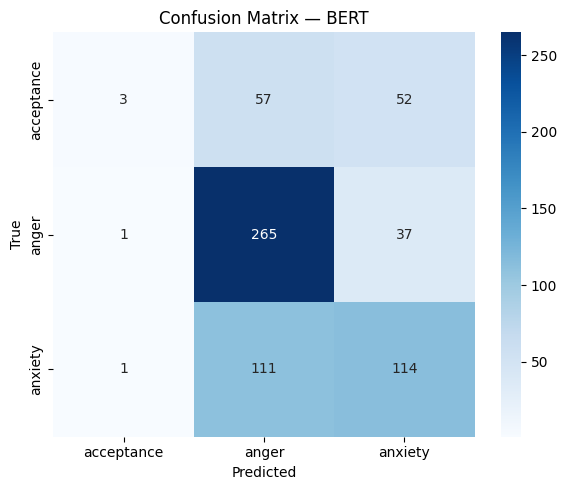


═══════════════════════════════════════════════════════
   Perbandingan Semua Model
═══════════════════════════════════════════════════════
        accuracy  f1_macro  f1_weighted  mae_healing
CNN       0.9579    0.9522       0.9578       0.1327
BiLSTM    0.9282    0.9193       0.9281       0.1345
BiGRU     0.9080    0.8885       0.9068       0.1258
BERT      0.5959    0.4343       0.5367       0.2461
LSTM      0.4727    0.2140       0.3034       0.2235
GRU       0.4727    0.2140       0.3034       0.2200
═══════════════════════════════════════════════════════

✓ Model terbaik : CNN
  F1 Macro      : 0.9522
  Accuracy      : 0.9579  ✓ > 0.85
  MAE Healing   : 0.1327  ✓ < 0.2


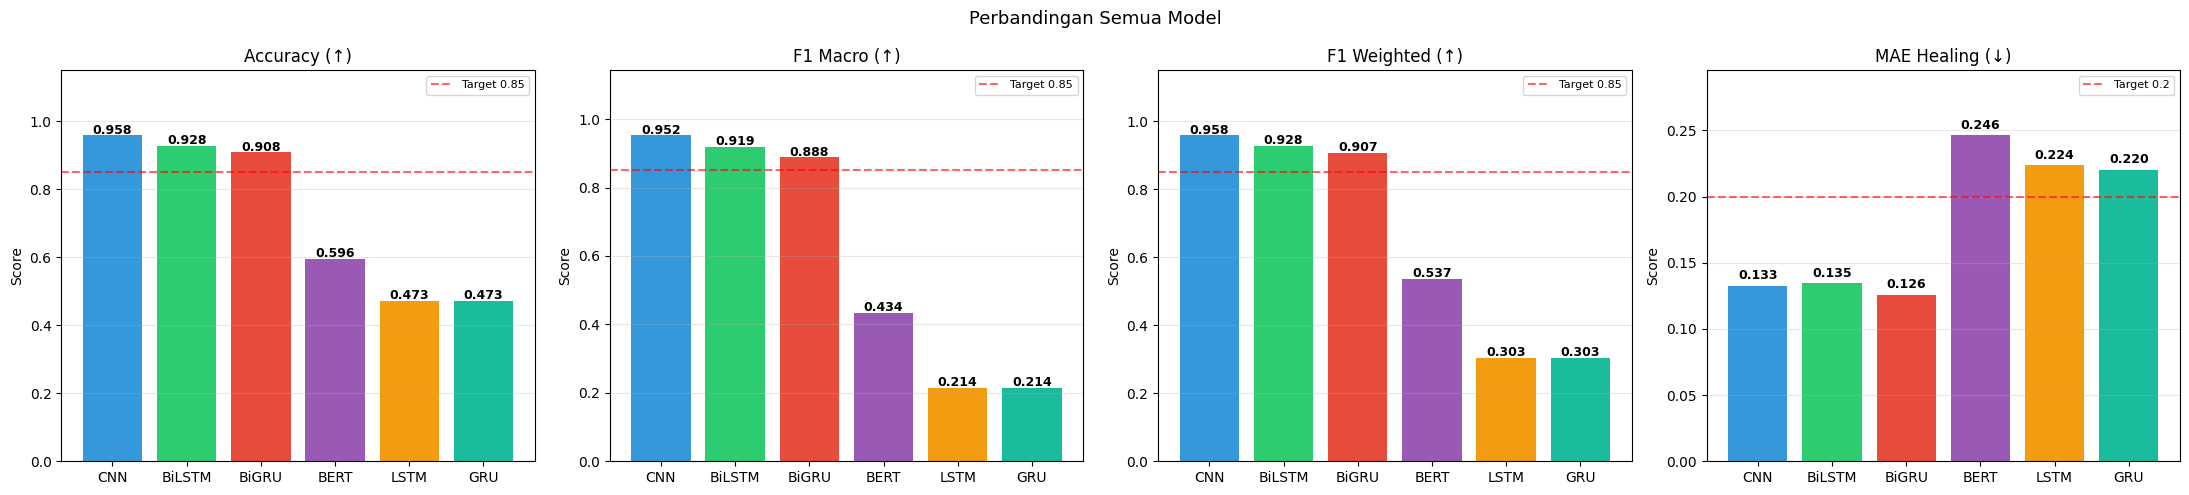

In [28]:
all_trainers = {
    'LSTM'  : trainer_LSTM,
    'GRU'   : trainer_GRU,
    'CNN'   : trainer_CNN,
    'BiLSTM': trainer_BiLSTM,
    'BiGRU' : trainer_BiGRU,
}

eval_results = {}
for name, trainer in all_trainers.items():
    eval_results[name] = trainer.evaluate(test_ds, y_test, yh_test, le)

eval_results['BERT'] = trainer_BERT.evaluate(bert_test_ds, y_test, yh_test, le)

eval_df        = pd.DataFrame(eval_results).T.round(4)
eval_df_sorted = eval_df.sort_values('f1_macro', ascending=False)

best_model_name = eval_df_sorted.index[0]

print("\n═══════════════════════════════════════════════════════")
print("   Perbandingan Semua Model")
print("═══════════════════════════════════════════════════════")
print(eval_df_sorted.to_string())
print("═══════════════════════════════════════════════════════")
print(f"\n✓ Model terbaik : {best_model_name}")
print(f"  F1 Macro      : {eval_df_sorted['f1_macro'].iloc[0]:.4f}")
print(f"  Accuracy      : {eval_df_sorted['accuracy'].iloc[0]:.4f}  "
      f"{'✓ > 0.85' if eval_df_sorted['accuracy'].iloc[0] >= 0.85 else '✗ < 0.85'}")
print(f"  MAE Healing   : {eval_df_sorted['mae_healing'].iloc[0]:.4f}  "
      f"{'✓ < 0.2' if eval_df_sorted['mae_healing'].iloc[0] < 0.2 else '✗ > 0.2'}")

# Plot perbandingan 4 metrik
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Perbandingan Semua Model', fontsize=13)

metrics_plot = ['accuracy', 'f1_macro', 'f1_weighted', 'mae_healing']
titles_plot  = ['Accuracy (↑)', 'F1 Macro (↑)', 'F1 Weighted (↑)', 'MAE Healing (↓)']
colors       = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c']
targets      = [0.85, 0.85, 0.85, 0.2]

for ax, metric, title, target in zip(axes, metrics_plot, titles_plot, targets):
    vals = eval_df_sorted[metric]
    bars = ax.bar(eval_df_sorted.index, vals, color=colors[:len(eval_df_sorted)])
    ax.set_title(title)
    ax.set_ylabel('Score')
    ax.set_ylim(0, max(vals.max() * 1.2, 0.1))
    ax.axhline(y=target, color='red', linestyle='--', alpha=0.6, label=f'Target {target}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## Simpan Model

In [ ]:
print("=" * 60)
print("  MENYIMPAN SEMUA MODEL")
print("=" * 60)

all_trainers_full = {**all_trainers, 'BERT': trainer_BERT}

print("\n[1] Simpan semua model → .keras")
for name, trainer in all_trainers_full.items():
    path = os.path.join(OUTPUT_DIR, f'{name}_final.keras')
    trainer.model.save(path)
    print(f"  ✓ {name:8s} → {path}")

print(f"\n[2] Simpan model terbaik ({best_model_name}) → best_model.keras")
best_trainer    = all_trainers_full[best_model_name]
best_keras_path = os.path.join(OUTPUT_DIR, 'best_model.keras')
best_trainer.model.save(best_keras_path)
print(f"  ✓ {best_keras_path}")

print("\n[3] Ekspor semua model → SavedModel format")
for name, trainer in all_trainers_full.items():
    sm_path = os.path.join(ALL_MODELS_DIR, name)
    trainer.model.export(sm_path)
    print(f"  ✓ {name:8s} → {sm_path}")

print(f"\n[4] Ekspor model terbaik ({best_model_name}) → SavedModel/best")
best_sm_path = os.path.join(BEST_MODEL_DIR, 'best_model')
best_trainer.model.export(best_sm_path)
print(f"  ✓ {best_sm_path}")

eval_export = {
    name: {k: float(v) for k, v in m.items()}
    for name, m in eval_results.items()
}
eval_export['_meta'] = {
    'best_model'      : best_model_name,
    'best_f1_macro'   : float(eval_df_sorted['f1_macro'].iloc[0]),
    'best_accuracy'   : float(eval_df_sorted['accuracy'].iloc[0]),
    'best_mae_healing': float(eval_df_sorted['mae_healing'].iloc[0]),
}
json_path = os.path.join(ARTIFACTS_DIR, 'eval_results.json')
with open(json_path, 'w') as f:
    json.dump(eval_export, f, indent=2)

print(f"\n{'═'*60}")
print(f"  ✓ Model terbaik    : {best_model_name}")
print(f"  ✓ Accuracy         : {eval_df_sorted['accuracy'].iloc[0]:.4f}")
print(f"  ✓ F1 Macro         : {eval_df_sorted['f1_macro'].iloc[0]:.4f}")
print(f"  ✓ MAE Healing      : {eval_df_sorted['mae_healing'].iloc[0]:.4f}")
print(f"  ✓ .keras path      : {best_keras_path}")
print(f"  ✓ SavedModel best  : {best_sm_path}")
print(f"  ✓ Eval JSON        : {json_path}")
print(f"{'═'*60}")

  MENYIMPAN SEMUA MODEL

[1] Simpan semua model → .keras
  ✓ LSTM     → ./results\LSTM_final.keras
  ✓ GRU      → ./results\GRU_final.keras
  ✓ CNN      → ./results\CNN_final.keras
  ✓ BiLSTM   → ./results\BiLSTM_final.keras
  ✓ BiGRU    → ./results\BiGRU_final.keras
  ✓ BERT     → ./results\BERT_final.keras

[2] Simpan model terbaik (CNN) → best_model.keras
  ✓ ./results\best_model.keras

[3] Ekspor semua model → SavedModel format
INFO:tensorflow:Assets written to: ./results/all_models\LSTM\assets


INFO:tensorflow:Assets written to: ./results/all_models\LSTM\assets


Saved artifact at './results/all_models\LSTM'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 200), dtype=tf.int32, name='input')
Output Type:
  Tuple[TensorSpec(shape=(None, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)]
Captures:
  2124025908880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124027847952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124025909264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124025909072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124025910800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124025911184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124025910224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124025912720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124025911952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124094497296: TensorSpec(shape=(), dtype=tf.

INFO:tensorflow:Assets written to: ./results/all_models\GRU\assets


Saved artifact at './results/all_models\GRU'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 200), dtype=tf.int32, name='input')
Output Type:
  Tuple[TensorSpec(shape=(None, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)]
Captures:
  2124337222416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124337222032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124337220880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124337221840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124337223376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124337223952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124337223760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124337224336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124337224144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124337225104: TensorSpec(shape=(), dtype=tf.r

...

Saved artifact at './results/all_models\BiGRU'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 200), dtype=tf.int32, name='input')
Output Type:
  Tuple[TensorSpec(shape=(None, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)]
Captures:
  2124737222544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124737221392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124737223120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124737221776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124737222736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124737223696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124737223504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124737224272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124737224848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124737224656: TensorSpec(shape=(), dtype=tf

INFO:tensorflow:Assets written to: ./results/all_models\BERT\assets


Saved artifact at './results/all_models\BERT'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 128), dtype=tf.int32, name='input_ids'), TensorSpec(shape=(None, 128), dtype=tf.int32, name='attention_mask'), TensorSpec(shape=(None, 128), dtype=tf.int32, name='token_type_ids')]
Output Type:
  Tuple[TensorSpec(shape=(None, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)]
Captures:
  2126814908240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2126814908816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2126814907664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2126814907856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2126814907472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2126814909392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2126814909200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2126814908432: TensorSpec(shape

INFO:tensorflow:Assets written to: ./results/best_model\best_model\assets


Saved artifact at './results/best_model\best_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 200), dtype=tf.int32, name='input')
Output Type:
  Tuple[TensorSpec(shape=(None, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)]
Captures:
  2124027848720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124522531984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124668038864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124668038480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124668039056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124668038672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124664445392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124664445584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124664445200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2124664445008: TensorSpec(shape=(), dty

## Inference

In [30]:
import sys
import os
import importlib.util


notebook_dir = os.getcwd()
while not os.path.exists(os.path.join(notebook_dir, 'DS')):
    parent = os.path.dirname(notebook_dir)
    if parent == notebook_dir: 
        raise FileNotFoundError("Folder 'DS' tidak ditemukan. Pastikan notebook berada di workspace yang benar.")
    notebook_dir = parent

# Path ke preprocessing file
prep_path = os.path.join(notebook_dir, 'DS', 'Emotion Label', 'preprocessing.py')

# Load dengan importlib
spec = importlib.util.spec_from_file_location("preprocessing", prep_path)
prep = importlib.util.module_from_spec(spec)
spec.loader.exec_module(prep)

print(f"✓ Preprocessing module loaded dari: {prep_path}")


def predict_non_bert(text, model, tokenizer, le, max_length=MAX_LENGTH):
    text = prep.clean_text(text)
    seq    = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=max_length, padding='post', truncating='post')

    pred_e, pred_h = model.predict(padded, verbose=0)
    probs          = pred_e[0]
    idx            = np.argmax(probs)

    return {
        'text'         : text,
        'prediksi'     : le.classes_[idx],
        'confidence'   : float(probs[idx]),
        'semua'        : {le.classes_[i]: float(p) for i, p in enumerate(probs)},
        'healing_score': float(pred_h[0][0]),
    }


def predict_bert(text, model, bert_tokenizer, le, max_length=BERT_MAX_LENGTH):
    text = prep.clean_text(text)
    encoded = bert_tokenizer(
        text,
        max_length     = max_length,
        padding        = 'max_length',
        truncation     = True,
        return_tensors = 'tf'
    )
    inputs = {
        'input_ids'     : encoded['input_ids'],
        'attention_mask': encoded['attention_mask'],
        'token_type_ids': encoded['token_type_ids'],
    }
    pred_e, pred_h = model.predict(inputs, verbose=0)
    probs          = pred_e[0]
    idx            = np.argmax(probs)

    return {
        'text'         : text,
        'prediksi'     : le.classes_[idx],
        'confidence'   : float(probs[idx]),
        'semua'        : {le.classes_[i]: float(p) for i, p in enumerate(probs)},
        'healing_score': float(pred_h[0][0]),
    }


def predict_all(text, all_trainers, trainer_bert, tokenizer, bert_tokenizer, le):

    print(f"\n{'═'*65}")
    print(f"  [ALL MODE]")
    print(f"  Input : \"{text}\"")
    print(f"{'═'*65}")

    results = {}

    for name, trainer in all_trainers.items():
        res           = predict_non_bert(text, trainer.model, tokenizer, le)
        results[name] = res
        print(f"\n  [{name}]")
        print(f"    Emosi         : {res['prediksi']} ({res['confidence']:.2%})")
        print(f"    Healing Score : {res['healing_score']:.4f}")
        print(f"    Distribusi    : { {k: f'{v:.2%}' for k, v in res['semua'].items()} }")

    res_bert        = predict_bert(text, trainer_bert.model, bert_tokenizer, le)
    results['BERT'] = res_bert
    print(f"\n  [BERT]")
    print(f"    Emosi         : {res_bert['prediksi']} ({res_bert['confidence']:.2%})")
    print(f"    Healing Score : {res_bert['healing_score']:.4f}")
    print(f"    Distribusi    : { {k: f'{v:.2%}' for k, v in res_bert['semua'].items()} }")

    # Voting majority emosi
    votes       = [r['prediksi'] for r in results.values()]
    majority    = max(set(votes), key=votes.count)
    vote_counts = {label: votes.count(label) for label in le.classes_}

    # Rata-rata healing score semua model
    avg_healing = float(np.mean([r['healing_score'] for r in results.values()]))

    print(f"\n{'─'*65}")
    print(f"  Voting Emosi   : {vote_counts}")
    print(f"  Emosi Final    : {majority} ({votes.count(majority)}/{len(votes)} model sepakat)")
    print(f"  Healing Score  : {avg_healing:.4f} (rata-rata semua model)")
    print(f"{'═'*65}\n")

    return results, majority, avg_healing


def predict_best(text, best_model_name, all_trainers, trainer_bert,
                 tokenizer, bert_tokenizer, le):
    print(f"\n{'═'*65}")
    print(f"  [BEST MODE — {best_model_name}]")
    print(f"  Input : \"{text}\"")
    print(f"{'═'*65}")

    if best_model_name == 'BERT':
        res = predict_bert(text, trainer_bert.model, bert_tokenizer, le)
    else:
        res = predict_non_bert(text, all_trainers[best_model_name].model, tokenizer, le)

    print(f"\n  Emosi         : {res['prediksi']} ({res['confidence']:.2%})")
    print(f"  Healing Score : {res['healing_score']:.4f}")
    print(f"  Distribusi    : { {k: f'{v:.2%}' for k, v in res['semua'].items()} }")
    print(f"{'═'*65}\n")

    return res


# RUN INFERENCE

test_sentences = [
    "I feel so sad and hopeless, nothing seems to go right",
    "Today was absolutely amazing, I am so happy!",
    "I am furious about what just happened, this is unacceptable",
    "I don't know what to feel anymore, everything is numb",
]

# ── ALL MODE ────────────────────────────────────────────────
print("=" * 65)
print("  INFERENCE — ALL MODE (semua 6 model)")
print("=" * 65)

for sentence in test_sentences:
    predict_all(
        text           = sentence,
        all_trainers   = all_trainers,
        trainer_bert   = trainer_BERT,
        tokenizer      = tokenizer,
        bert_tokenizer = bert_tokenizer,
        le             = le
    )

# ── BEST MODE ───────────────────────────────────────────────
print("\n" + "=" * 65)
print(f"  INFERENCE — BEST MODE (model terbaik: {best_model_name})")
print("=" * 65)

for sentence in test_sentences:
    predict_best(
        text            = sentence,
        best_model_name = best_model_name,
        all_trainers    = all_trainers,
        trainer_bert    = trainer_BERT,
        tokenizer       = tokenizer,
        bert_tokenizer  = bert_tokenizer,
        le              = le
    )

✓ Preprocessing module loaded dari: d:\Farizky\casptoneAfterCrash\healmate_ai\DS\Emotion Label\preprocessing.py
  INFERENCE — ALL MODE (semua 6 model)

═════════════════════════════════════════════════════════════════
  [ALL MODE]
  Input : "I feel so sad and hopeless, nothing seems to go right"
═════════════════════════════════════════════════════════════════

  [LSTM]
    Emosi         : anger (47.17%)
    Healing Score : -0.1349
    Distribusi    : {'acceptance': '18.32%', 'anger': '47.17%', 'anxiety': '34.50%'}

  [GRU]
    Emosi         : anger (46.94%)
    Healing Score : -0.1456
    Distribusi    : {'acceptance': '17.78%', 'anger': '46.94%', 'anxiety': '35.28%'}

  [CNN]
    Emosi         : anxiety (100.00%)
    Healing Score : -0.1746
    Distribusi    : {'acceptance': '0.00%', 'anger': '0.00%', 'anxiety': '100.00%'}

  [BiLSTM]
    Emosi         : anxiety (97.18%)
    Healing Score : -0.2511
    Distribusi    : {'acceptance': '0.59%', 'anger': '2.23%', 'anxiety': '97.18%'}



  [BiGRU]
    Emosi         : anxiety (93.61%)
    Healing Score : -0.1616
    Distribusi    : {'acceptance': '3.35%', 'anger': '3.04%', 'anxiety': '93.61%'}



  [BERT]
    Emosi         : anxiety (57.99%)
    Healing Score : -0.2998
    Distribusi    : {'acceptance': '9.03%', 'anger': '32.98%', 'anxiety': '57.99%'}

─────────────────────────────────────────────────────────────────
  Voting Emosi   : {'acceptance': 0, 'anger': 2, 'anxiety': 4}
  Emosi Final    : anxiety (4/6 model sepakat)
  Healing Score  : -0.1946 (rata-rata semua model)
═════════════════════════════════════════════════════════════════


═════════════════════════════════════════════════════════════════
  [ALL MODE]
  Input : "Today was absolutely amazing, I am so happy!"
═════════════════════════════════════════════════════════════════

  [LSTM]
    Emosi         : anger (47.17%)
    Healing Score : -0.1349
    Distribusi    : {'acceptance': '18.32%', 'anger': '47.17%', 'anxiety': '34.50%'}

  [GRU]
    Emosi         : anger (46.94%)
    Healing Score : -0.1456
    Distribusi    : {'acceptance': '17.78%', 'anger': '46.94%', 'anxiety': '35.28%'}

  [CNN]
    Emosi         :